## Etapa 0 - Estabelecer o Dataset

- Entender como está estrutura o dataset, quais são as colunas, o que cada coluna representa
- Chegar a um requisito inicial de 200 mil palavras para a análise de palavras

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/damarals/biblias/main/inst/json/NVT.json'

dfb = pd.read_json(url)

dfb.head()
dfb_joao = dfb[dfb['name'] == 'João']
# Mostrar o DataFrame atualizado
dfb_joao.head()

# Para acessar capitulos
# joao_chapters = dfb_joao['chapters'].iloc[0]

,abbrev,chapters,name
42,Jo,"[[No princípio, aquele que é a Palavra já exis...",João


### Análise da Estrutura do Dataset - Livro de João

Verificar como os capítulos e versículos estão organizados no dataset.

In [2]:
# Extrair dados do livro de João
joao_data = dfb_joao.iloc[0]
joao_chapters = joao_data['chapters']

# 1. Informações gerais
print(f"\n1. INFORMAÇÕES GERAIS:")
print(f"   - Nome do livro: {joao_data['name']}")
print(f"   - Abreviação: {joao_data.get('abbrev', 'N/A')}")
print(f"   - Tipo de 'chapters': {type(joao_chapters)}")
print(f"   - Total de capítulos: {len(joao_chapters)}")

# 2. Criar DataFrame estruturado por capítulo
chapter_data = []
total_verses = 0

for chapter_num, chapter_verses in enumerate(joao_chapters, start=1):
    num_verses = len(chapter_verses)
    total_verses += num_verses

    # Contar palavras no capítulo
    chapter_words = sum(len(verse.split()) for verse in chapter_verses)

    # Pegar exemplo do primeiro versículo
    first_verse_preview = chapter_verses[0][:80] + "..." if len(chapter_verses[0]) > 80 else chapter_verses[0]

    chapter_data.append({
        'Capítulo': chapter_num,
        'Num_Versículos': num_verses,
        'Total_Palavras': chapter_words,
        'Primeiro_Versículo': first_verse_preview
    })

# Criar DataFrame
df_joao_structure = pd.DataFrame(chapter_data)

print(f"\n2. RESUMO ESTATÍSTICO:")
print(f"   - Total de versículos no livro: {total_verses}")
print(f"   - Total de palavras no livro: {df_joao_structure['Total_Palavras'].sum()}")
print(f"   - Média de versículos por capítulo: {df_joao_structure['Num_Versículos'].mean():.1f}")
print(f"   - Média de palavras por capítulo: {df_joao_structure['Total_Palavras'].mean():.1f}")

print(f"\n3. ESTRUTURA POR CAPÍTULO:")
display(df_joao_structure)

# 3. Exemplo detalhado de um capítulo específico (Capítulo 1)
print(f"\n4. EXEMPLO DETALHADO - CAPÍTULO 1:")
print(f"   - Número de versículos: {len(joao_chapters[0])}")
print(f"\n   Primeiros 5 versículos:")

for verse_num, verse_text in enumerate(joao_chapters[0][:5], start=1):
    print(f"   [{verse_num}] {verse_text}")

# 4. Verificar se há estrutura aninhada adicional
print(f"\n5. VERIFICAÇÃO DE ANINHAMENTO:")
sample_verse = joao_chapters[0][0]
print(f"   - Tipo do primeiro versículo: {type(sample_verse)}")
print(f"   - É uma string? {'✓ SIM' if isinstance(sample_verse, str) else '✗ NÃO (estrutura aninhada detectada)'}")

if isinstance(sample_verse, str):
    print(f"   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string")
else:
    print(f"   - ATENÇÃO: Estrutura mais complexa detectada!")
    print(f"   - Conteúdo do primeiro item: {sample_verse}")


1. INFORMAÇÕES GERAIS:
   - Nome do livro: João
   - Abreviação: Jo
   - Tipo de 'chapters': <class 'list'>
   - Total de capítulos: 21

2. RESUMO ESTATÍSTICO:
   - Total de versículos no livro: 879
   - Total de palavras no livro: 16840
   - Média de versículos por capítulo: 41.9
   - Média de palavras por capítulo: 801.9

3. ESTRUTURA POR CAPÍTULO:


,Capítulo,Num_Versículos,Total_Palavras,Primeiro_Versículo
0,1,51,918,"No princípio, aquele que é a Palavra já existi..."
1,2,25,461,"Três dias depois, houve uma festa de casamento..."
2,3,36,713,"Havia um fariseu chamado Nicodemos, líder reli..."
3,4,54,1027,Jesus sabia que os fariseus tinham ouvido dize...
4,5,47,928,"Depois disso, Jesus voltou a Jerusalém para um..."
5,6,71,1275,"Depois disso, Jesus atravessou o mar da Galile..."
6,7,53,955,"Depois disso, Jesus viajou pela Galileia. Quer..."
7,8,59,1172,"Jesus voltou ao monte das Oliveiras,"
8,9,41,749,"Enquanto caminhava, Jesus viu um homem cego de..."
9,10,42,735,“Eu lhes digo a verdade: quem entra no curral ...



4. EXEMPLO DETALHADO - CAPÍTULO 1:
   - Número de versículos: 51

   Primeiros 5 versículos:
   [1] No princípio, aquele que é a Palavra já existia. A Palavra estava com Deus, e a Palavra era Deus.
   [2] Ele existia no princípio com Deus.
   [3] Por meio dele Deus criou todas as coisas, e sem ele nada foi criado.
   [4] Aquele que é a Palavra possuía a vida, e sua vida trouxe luz a todos.
   [5] A luz brilha na escuridão, e a escuridão nunca conseguiu apagá-la.

5. VERIFICAÇÃO DE ANINHAMENTO:
   - Tipo do primeiro versículo: <class 'str'>
   - É uma string? ✓ SIM
   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string


In [3]:
import pandas as pd

dfb_full = dfb

# Define lists of books for the New Testament and Wisdom books (Old Testament)
new_testament_books = [
    'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios',
    'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses',
    '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro',
    '1 João', '2 João', '3 João', 'Judas', 'Apocalipse'
]

wisdom_books_ot = [
    'Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos'
]

# Combine the lists of desired books
selected_books = new_testament_books + wisdom_books_ot

# Filter the DataFrame for these selected books
dfb_selected = dfb_full[dfb_full['name'].isin(selected_books)].copy()

# Initialize total word count for all selected books
total_words_all_selected_books = 0

print(f"Starting word count for {len(selected_books)} selected books:\n")

# Iterate through each selected book to count words
for index, row in dfb_selected.iterrows():
    book_name = row['name']
    book_chapters_data = row['chapters'] # This could be a complex nested structure
    current_book_word_count = 0

    # Flatten book_chapters_data into a single list of all verse strings
    all_verses_for_book = []

    def flatten_list_of_lists(nested_list):
        for item in nested_list:
            if isinstance(item, list):
                yield from flatten_list_of_lists(item)
            else:
                yield item

    # Apply flattening. This handles arbitrary levels of nesting until strings are found.
    for verse_candidate in flatten_list_of_lists(book_chapters_data):
        if isinstance(verse_candidate, str):
            all_verses_for_book.append(verse_candidate)
        else:
            # This case indicates an unexpected non-string item after deep flattening
            print(f"Warning: Found non-string item in {book_name} after flattening: {verse_candidate} (type: {type(verse_candidate)}) - skipping")

    # Now, all_verses_for_book should be a flat list of strings
    for verse_text in all_verses_for_book:
        words = verse_text.split() # verse_text is guaranteed to be a string here
        current_book_word_count += len(words)

    print(f"  Book: {book_name} - Total words: {current_book_word_count}")
    total_words_all_selected_books += current_book_word_count

print(f"\n------------------------------------------------")
print(f"Total words across all selected books: {total_words_all_selected_books}")


Starting word count for 32 selected books:

  Book: Jó - Total words: 15419
  Book: Salmos - Total words: 36889
  Book: Provérbios - Total words: 13210
  Book: Eclesiastes - Total words: 4724
  Book: Cânticos - Total words: 2449
  Book: Mateus - Total words: 20990
  Book: Marcos - Total words: 13305
  Book: Lucas - Total words: 22346
  Book: João - Total words: 16840
  Book: Atos - Total words: 21569
  Book: Romanos - Total words: 9899
  Book: 1 Coríntios - Total words: 9364
  Book: 2 Coríntios - Total words: 6100
  Book: Gálatas - Total words: 3215
  Book: Efésios - Total words: 2992
  Book: Filipenses - Total words: 2197
  Book: Colossenses - Total words: 2045
  Book: 1 Tessalonicenses - Total words: 1801
  Book: 2 Tessalonicenses - Total words: 1018
  Book: 1 Timóteo - Total words: 2419
  Book: 2 Timóteo - Total words: 1748
  Book: Tito - Total words: 1042
  Book: Filemom - Total words: 430
  Book: Hebreus - Total words: 6792
  Book: Tiago - Total words: 2172
  Book: 1 Pedro - Total

## Etapa 1 - **Pré-processamento Textual**

Etapa para preparar o texto da Bíblia em português.

In [4]:
# 1. Instalação de dependências e download de modelos
!pip install -q spacy nltk pandas gensim scikit-learn wordcloud
!python -m spacy download pt_core_news_md

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
import pandas as pd
import re
from collections import Counter
from typing import List, Dict, Any
import json
from pathlib import Path

# Downloads necessários para o NLTK
nltk.download('stopwords')
nltk.download('rslp')

print("\n[INFO] Ambiente configurado com sucesso.")
# O modelo 'pt_core_news_sm' é essencial para o spaCy processar a língua portuguesa,
# permitindo análise morfológica e lemmatização precisa, diferente de modelos em inglês
# que utilizam regras gramaticais e vocabulários distintos.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 75.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 8.8 MB/s eta 0:00:00:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...



[INFO] Ambiente configurado com sucesso.


[nltk_data]   Unzipping stemmers/rslp.zip.


### Normalização de Clíticos

**Motivação**

O português possui alta variação morfológica e ortográfica em formas verbais e pronominais, por exemplo:

- flexão verbal
- composição com pronomes
- hifenização
- variações antigas da linguagem

Isso faz o vocabulário "explodir" artificialmente, prejudicando a qualidade de lematização e a consistência dos tópicos.

**Exemplos de variação encontradas no vocabulario**

- "ajoelhar se"
- "ajoelhar-se"
- "ajoelhavam-se"
- "ajoelhou se"
- "ajoelhou-se"
- "ajoelhour se"
- "ajuda nós"
- "ajuda-a"
- "ajuda-me"
- "ajuda-nos"
- "ajuda-o"
- "ajuda-os"

**Impacto esperado**

A normalização ocorre antes do spaCy, reduzindo variações superficiais e aumentando a chance de o lematizador convergir para a forma canônica. Isso tende a melhorar a densidade semântica e a estabilidade dos tópicos.

In [5]:
def normalize_clitics(text: str) -> str:
    """Remove pronomes encliticos comuns do portugues."""
    pattern = r'-(me|te|se|na|nas|no|nos|vos|lo|los|la|las|lhe|lhes|o|a|os|as)\b'
    return re.sub(pattern, '', text)


class BiblePreprocessor:
    """Classe para pre-processamento de texto biblico focado em Topic Modeling."""

    def __init__(self, custom_stopwords: List[str] = None):
        # Carregando spaCy pt_core_news_md para analise contextual
        self.nlp = spacy.load("pt_core_news_md")

        # Configuracao de Stopwords (NLTK + Custom)
        base_stopwords = set(stopwords.words('portuguese'))
        if custom_stopwords:
            base_stopwords.update(custom_stopwords)
        self.stop_words = base_stopwords

        self.stemmer = RSLPStemmer()  # Para comparacao academica
        
        # Dicionário de correções de lemmatização para termos religiosos
        # O modelo spaCy comete erros em alguns termos bíblicos específicos
        self.lemma_corrections = {
            'cristar': 'cristo',  # spaCy erroneamente lemmatiza "cristo" como "cristar"
            'agrar': 'agradar'
        }

    def clean_text(self, text: str) -> str:
        """Limpeza inicial: remocao de ruidos basicos."""
        text = text.lower()
        text = re.sub(r'\d+', '', text)  # Remove numeros
        text = re.sub(r'\s+', ' ', text).strip()  # Remove espacos extras
        return text

    def process_pipeline(self, text: str) -> List[str]:
        """
        Executa normalizacao de cliticos, Tokenizacao, Lematizacao e POS Filtering.
        Mantem apenas NOUN, VERB, ADJ para densidade semantica no Topic Modeling.
        """
        text = normalize_clitics(text)
        text = self.clean_text(text)
        doc = self.nlp(text)

        tokens_limpos = []
        for token in doc:
            # POS Filtering: Substantivos, Verbos e Adjetivos carregam o topico
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']:
                # Lematizacao para reduzir dimensionalidade sem perder semantica
                lemma = token.lemma_
                
                # Aplicar correções customizadas de lemmatização
                lemma = self.lemma_corrections.get(lemma, lemma)
                
                if lemma not in self.stop_words and len(lemma) >= 2:
                    tokens_limpos.append(lemma)

        return tokens_limpos

In [7]:
# ============================================================================
# EXTRAÇÃO E PREPROCESSAMENTO DE VERSÍCULOS
# ============================================================================

custom_stops = ['capítulo', 'versículo', 'bíblia', 'livro']
preprocessor = BiblePreprocessor(custom_stopwords=custom_stops)

print(f"[INFO] Processando versículos de {len(dfb_selected)} livros selecionados...")
print(f"[INFO] Extraindo versículos individuais...\n")

# Estruturas sincronizadas por índice
corpus_verses = []        # Lista de listas de tokens preprocessados
verse_metadata = []       # Lista de dicts com metadados
versiculos_curtos = 0     # Contador de versículos muito curtos (filtrados)

# Iterar sobre cada livro selecionado
for _, row in dfb_selected.iterrows():
    book_name = row['name']
    chapters_data = row['chapters']
    
    # Iterar sobre capítulos e versículos
    for chapter_num, chapter_verses in enumerate(chapters_data, start=1):
        for verse_num, verse_text in enumerate(chapter_verses, start=1):
            # Garantir que verse_text é uma string
            if isinstance(verse_text, list):
                # Se for lista, juntar os elementos
                verse_text = ' '.join(str(item) for item in verse_text)
            elif not isinstance(verse_text, str):
                # Se não for string nem lista, converter para string
                verse_text = str(verse_text)
            
            # Preprocessar versículo
            verse_tokens = preprocessor.process_pipeline(verse_text)
            
            # Filtrar versículos muito curtos (< 3 tokens após preprocessing)
            if len(verse_tokens) < 3:
                versiculos_curtos += 1
                continue
            
            # Adicionar às estruturas sincronizadas
            corpus_verses.append(verse_tokens)
            verse_metadata.append({
                'book': book_name,
                'chapter': chapter_num,
                'verse_num': verse_num,
                'text': verse_text
            })

print(f"\n[RESULTADO] Corpus de versículos criado:")
print(f"  - Total de versículos extraídos: {len(corpus_verses) + versiculos_curtos}")
print(f"  - Versículos após filtragem (<3 tokens): {len(corpus_verses)}")
print(f"  - Versículos filtrados: {versiculos_curtos}")
print(f"  - Sincronização: len(corpus_verses) == len(verse_metadata) = {len(corpus_verses) == len(verse_metadata)}")

# Exemplos de versículos processados
print(f"\n[EXEMPLO] Primeiro versículo ({verse_metadata[0]['book']} {verse_metadata[0]['chapter']}:{verse_metadata[0]['verse_num']}):")
print(f"  - Texto original: {verse_metadata[0]['text'][:80]}...")
print(f"  - Tokens preprocessados: {corpus_verses[0][:10]}...")

[INFO] Processando versículos de 32 livros selecionados...
[INFO] Extraindo versículos individuais...


[RESULTADO] Corpus de versículos criado:
  - Total de versículos extraídos: 12743
  - Versículos após filtragem (<3 tokens): 12590
  - Versículos filtrados: 153
  - Sincronização: len(corpus_verses) == len(verse_metadata) = True

[EXEMPLO] Primeiro versículo (Jó 1:1):
  - Texto original: Havia um homem chamado Jó que vivia na terra de Uz. Ele era íntegro e correto, t...
  - Tokens preprocessados: ['homem', 'chamar', 'viver', 'terra', 'íntegro', 'correto', 'temer', 'deus', 'manter', 'afastar']...


In [8]:
import numpy as np
# ============================================================================
# ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS
# ============================================================================

# Calcular estatísticas por livro
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS")
print("=" * 80)

book_verse_counts = {}
for meta in verse_metadata:
    book = meta['book']
    if book not in book_verse_counts:
        book_verse_counts[book] = 0
    book_verse_counts[book] += 1

print(f"\n[DISTRIBUIÇÃO] Versículos por livro:")
for book, count in list(book_verse_counts.items())[:10]:
    print(f"  - {book:20s}: {count:4d} versículos")
print(f"  ...")

# Estatísticas de tokens por versículo
verses_lengths = [len(tokens) for tokens in corpus_verses]
print(f"\n[ESTATÍSTICAS] Tokens por versículo:")
print(f"  - Média: {np.mean(verses_lengths):.1f} tokens")
print(f"  - Mediana: {np.median(verses_lengths):.1f} tokens")
print(f"  - Mínimo: {np.min(verses_lengths)} tokens")
print(f"  - Máximo: {np.max(verses_lengths)} tokens")

# Vocabulário total
all_tokens_flat = [t for doc in corpus_verses for t in doc]
vocabulario = sorted(list(set(all_tokens_flat)))

print(f"\n[VOCABULÁRIO] Termos únicos no corpus de versículos: {len(vocabulario)}")

# Persistência
output_path = Path("preprocessed_bible")
output_path.mkdir(exist_ok=True)

with open(output_path / "vocabulario_verses.json", "w", encoding="utf-8") as f:
    json.dump(vocabulario, f, ensure_ascii=False, indent=4)

# Salvar corpus de versículos
with open(output_path / "corpus_verses.txt", "w", encoding="utf-8") as f:
    for tokens in corpus_verses:
        f.write(" ".join(tokens) + "\n")

print(f"\n[INFO] Arquivos salvos em: {output_path}/")
print(f"  - vocabulario_verses.json")
print(f"  - corpus_verses.txt")



ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS

[DISTRIBUIÇÃO] Versículos por livro:
  - Jó                  : 1049 versículos
  - Salmos              : 2452 versículos
  - Provérbios          :  915 versículos
  - Eclesiastes         :  222 versículos
  - Cânticos            :  116 versículos
  - Mateus              : 1057 versículos
  - Marcos              :  661 versículos
  - Lucas               : 1135 versículos
  - João                :  850 versículos
  - Atos                :  995 versículos
  ...

[ESTATÍSTICAS] Tokens por versículo:
  - Média: 7.9 tokens
  - Mediana: 7.0 tokens
  - Mínimo: 3 tokens
  - Máximo: 27 tokens

[VOCABULÁRIO] Termos únicos no corpus de versículos: 7801

[INFO] Arquivos salvos em: preprocessed_bible/
  - vocabulario_verses.json
  - corpus_verses.txt


### Resultado Visual da Etapa 1: WordCloud

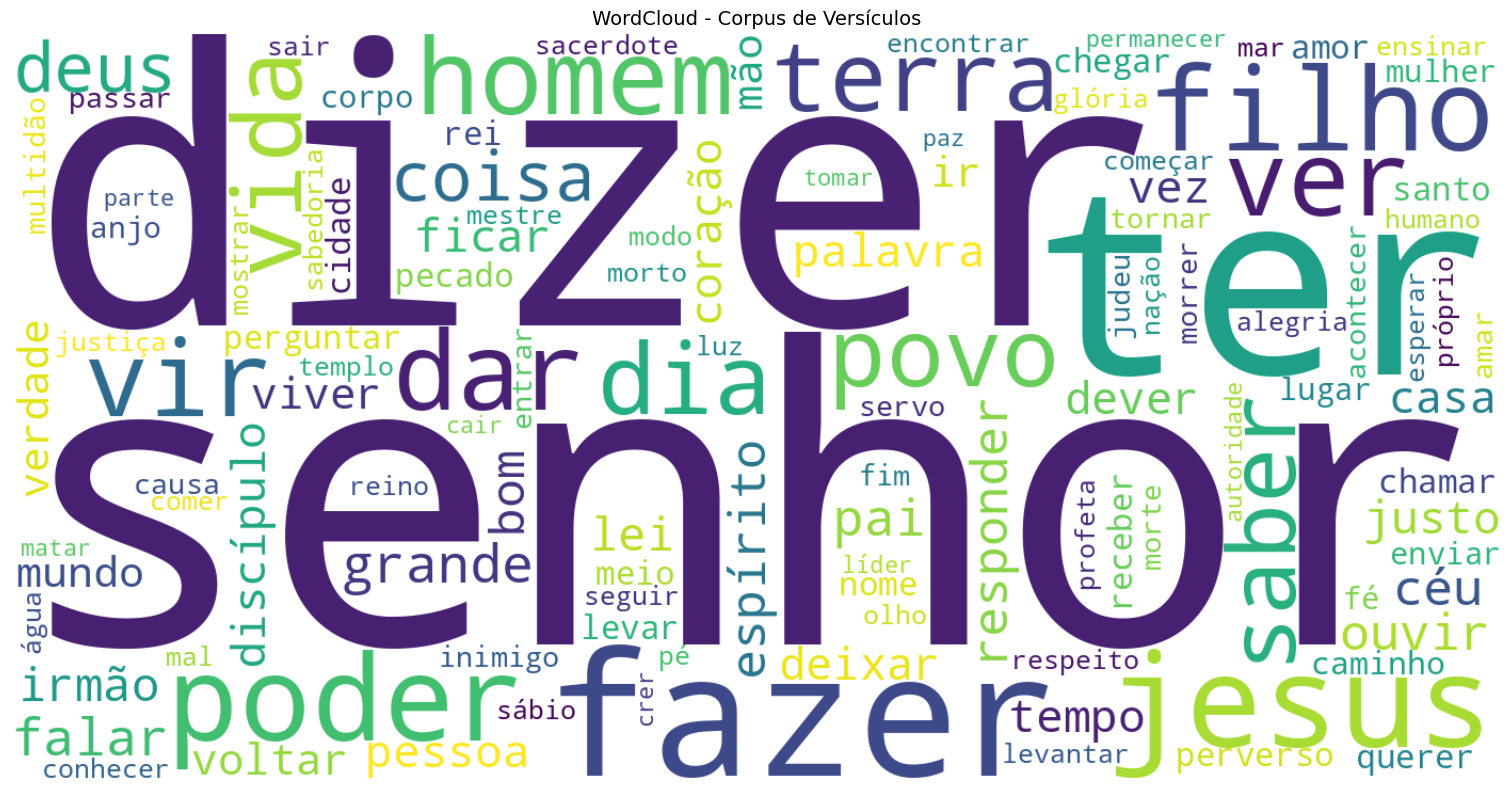


[INFO] WordCloud salva em: preprocessed_bible/wordcloud_verses.png


In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Garante que o corpus possui dados antes de gerar a visualização
if not all_tokens_flat:
    raise ValueError("all_tokens_flat está vazio. Execute a etapa de pré-processamento antes da WordCloud.")

# Frequências a partir do corpus de versículos preprocessado
frequencias = Counter(all_tokens_flat)

# Geração da WordCloud
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=120,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequencias)

# Exibição
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    f"WordCloud - Corpus de Versículos",
    fontsize=14
)
plt.tight_layout()
plt.show()

# Persistência em arquivo
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "wordcloud_verses.png"
wc.to_file(str(output_file))

## Distribuição de termos frequentes


In [11]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Análise de frequência do corpus de versículos
print("=" * 80)
print("ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS (CORPUS DE VERSÍCULOS)")
print("=" * 80)

# Estatísticas por livro (agregando versículos)
book_verse_stats = {}

for meta, tokens in zip(verse_metadata, corpus_verses):
    book = meta['book']
    if book not in book_verse_stats:
        book_verse_stats[book] = {
            'verse_count': 0,
            'total_tokens': 0,
            'all_tokens': []
        }
    
    book_verse_stats[book]['verse_count'] += 1
    book_verse_stats[book]['total_tokens'] += len(tokens)
    book_verse_stats[book]['all_tokens'].extend(tokens)

# Calcular estatísticas finais por livro
book_statistics = {}
for book, data in book_verse_stats.items():
    freq_counter = Counter(data['all_tokens'])
    stats = {
        'versiculos': data['verse_count'],
        'total_tokens': data['total_tokens'],
        'unique_terms': len(freq_counter),
        'tokens_per_verse': data['total_tokens'] / data['verse_count'] if data['verse_count'] > 0 else 0,
        'ttr': len(freq_counter) / data['total_tokens'] if data['total_tokens'] > 0 else 0
    }
    book_statistics[book] = stats

# Tabela comparativa de todos os livros
df_books_stats = pd.DataFrame(book_statistics).T
df_books_stats = df_books_stats.round(2)

print("\n[TABELA] Estatísticas por Livro (Corpus de Versículos):\n")
display(df_books_stats)

# Análise de Variação: Comparação entre Livros
print("\n[COMPARAÇÃO] Top 10 Livros por Número de Versículos:")
top_books_verses = df_books_stats.nlargest(10, 'versiculos')[['versiculos', 'total_tokens', 'tokens_per_verse']]
display(top_books_verses)

print("\n[COMPARAÇÃO] Top 10 Livros por Diversidade Lexical (TTR):")
top_books_ttr = df_books_stats.nlargest(10, 'ttr')[['versiculos', 'unique_terms', 'ttr']]
display(top_books_ttr)

ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS (CORPUS DE VERSÍCULOS)

[TABELA] Estatísticas por Livro (Corpus de Versículos):



,versiculos,total_tokens,unique_terms,tokens_per_verse,ttr
Jó,1049.0,6691.0,2086.0,6.38,0.31
Salmos,2452.0,15910.0,3002.0,6.49,0.19
Provérbios,915.0,6321.0,1784.0,6.91,0.28
Eclesiastes,222.0,2023.0,816.0,9.11,0.40
Cânticos,116.0,1069.0,539.0,9.22,0.50
Mateus,1057.0,8925.0,1950.0,8.44,0.22
Marcos,661.0,5609.0,1462.0,8.49,0.26
Lucas,1135.0,9409.0,2092.0,8.29,0.22
João,850.0,6511.0,1301.0,7.66,0.20
Atos,995.0,9012.0,1994.0,9.06,0.22



[COMPARAÇÃO] Top 10 Livros por Número de Versículos:


,versiculos,total_tokens,tokens_per_verse
Salmos,2452.0,15910.0,6.49
Lucas,1135.0,9409.0,8.29
Mateus,1057.0,8925.0,8.44
Jó,1049.0,6691.0,6.38
Atos,995.0,9012.0,9.06
Provérbios,915.0,6321.0,6.91
João,850.0,6511.0,7.66
Marcos,661.0,5609.0,8.49
Romanos,429.0,3839.0,8.95
1 Coríntios,428.0,3567.0,8.33



[COMPARAÇÃO] Top 10 Livros por Diversidade Lexical (TTR):


,versiculos,unique_terms,ttr
3 João,15.0,91.0,0.76
Judas,25.0,223.0,0.76
2 João,12.0,80.0,0.71
Filemom,25.0,117.0,0.70
2 Timóteo,83.0,443.0,0.62
Tito,46.0,282.0,0.61
2 Tessalonicenses,46.0,227.0,0.59
2 Pedro,61.0,366.0,0.59
Tiago,108.0,541.0,0.58
Filipenses,103.0,456.0,0.55


## Etapa 2 - **Representação vetorial e busca textual de versículos**

Nesta etapa, implementamos dois métodos de busca textual sobre **versículos individuais**:
- **TF-IDF** com TfidfVectorizer (sklearn)
- **Word2Vec** com Gensim

**Pipeline Refatorada**: Corpus de Versículos

A pipeline foi refatorada para trabalhar exclusivamente com versículos (~27-32 mil documentos) ao invés de livros (32 documentos). Isso permite:
- Busca com granularidade fina (retornar versículos específicos)
- Referências diretas (Livro Capítulo:Versículo)
- Contexto semântico local melhor capturado pelo Word2Vec

| Aspecto | TF-IDF | Word2Vec |
|---------|--------|----------|
| **Representação** | Esparsa (99%+ zeros) | Densa (todos valores preenchidos) |
| **Dimensionalidade** | ~15000 features (versículos) | 180 dimensões |
| **Captura** | Frequência estatística | Relações semânticas |
| **Melhor para** | Termos raros, palavras-chave específicas | Sinônimos, conceitos relacionados |
| **Limitação** | Ignora semântica (não sabe que "amar" ≈ "afeição") | Ignora frequência estatística |
| **Velocidade** | Rápido (sparse matrix operations) | Moderado (cálculo de média de embeddings) |
| **Ajustes para versículos** | `min_df=1` (capturar termos raros) | Treinado em ~30k documentos curtos |


In [12]:
# Instalar gensim para Word2Vec (sklearn já foi instalado na Etapa 1)
!pip install -q gensim

from typing import List, Tuple, Optional
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Bibliotecas carregadas com sucesso.")
print(f"[INFO] Corpus disponível: {len(corpus_verses)} versículos")
print(f"[INFO] Livros no corpus: {list(dfb_selected['name'])}")

[INFO] Bibliotecas carregadas com sucesso.
[INFO] Corpus disponível: 12590 versículos
[INFO] Livros no corpus: ['Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos', 'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios', 'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses', '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro', '1 João', '2 João', '3 João', 'Judas', 'Apocalipse']


In [13]:
# ============================================================================
# IMPLEMENTAÇÃO TF-IDF
# ============================================================================

# Preparar corpus de versículos: juntar tokens em strings
# TfidfVectorizer espera uma lista de strings (uma por documento)
corpus_verses_strings = [" ".join(tokens) for tokens in corpus_verses]

# Configurar TF-IDF Vectorizer ajustado para documentos curtos (versículos)
# min_df=1: versículos são curtos, capturar até termos que aparecem em 1 documento
# max_df=0.9: mais permissivo para corpus maior de documentos curtos
tfidf_vectorizer = TfidfVectorizer(
    max_features=None,        
    ngram_range=(1, 2),       # Captura unigramas e bigramas (ex: "espírito santo")
    min_df=1,                 # Documentos curtos: capturar termos raros
    max_df=0.9,               # Remove termos em mais de 90% dos versículos
    lowercase=True,           # Normalização (já feita no preprocessing, mas garantimos)
    token_pattern=r'(?u)\b\w+\b'  # Padrão de tokenização básico
)

# Ajustar o vectorizer ao corpus de versículos e transformar em matriz TF-IDF
print("[INFO] Treinando TF-IDF Vectorizer para corpus de versículos...")
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_verses_strings)

print(f"\n[RESULTADO] Matriz TF-IDF de versículos criada:")
print(f"  - Shape: {tfidf_matrix.shape} (versículos X features)")
print(f"  - Número de versículos: {tfidf_matrix.shape[0]}")
print(f"  - Tamanho do vocabulário: {tfidf_matrix.shape[1]}")
print(f"  - Densidade da matriz: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")
print(f"    (Representação esparsa: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}% zeros)")

# Exemplos de termos capturados
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n[VOCABULÁRIO] Exemplos de termos (unigramas e bigramas):")
print(f"  - Primeiros 10: {list(feature_names[:10])}")
print(f"  - Últimos 10: {list(feature_names[-10:])}")

# Procurar por bigramas religiosos no vocabulário
religious_bigrams = [term for term in feature_names if ' ' in term and any(keyword in term for keyword in ['santo', 'jesus', 'deus', 'senhor', 'espírito', 'cristo'])]
print(f"\n[BIGRAMAS RELIGIOSOS] Exemplos capturados: {religious_bigrams[:15]}")

[INFO] Treinando TF-IDF Vectorizer para corpus de versículos...

[RESULTADO] Matriz TF-IDF de versículos criada:
  - Shape: (12590, 68772) (versículos X features)
  - Número de versículos: 12590
  - Tamanho do vocabulário: 68772
  - Densidade da matriz: 0.0002
    (Representação esparsa: 99.98% zeros)

[VOCABULÁRIO] Exemplos de termos (unigramas e bigramas):
  - Primeiros 10: ['aba', 'aba pai', 'abadom', 'abadom grego', 'abaixar', 'abaixar desamarrar', 'abaixar olhar', 'abalado', 'abalado assustar', 'abalado direita']
  - Últimos 10: ['único soberano', 'único sugestão', 'único sábio', 'único ter', 'útil', 'útil conhecimento', 'útil ensinar', 'útil fim', 'útil ministério', 'útil mostrar']

[BIGRAMAS RELIGIOSOS] Exemplos capturados: ['abandone senhor', 'abandonem senhor', 'abater espírito', 'abatir senhor', 'abençoar cristo', 'abençoar senhor', 'abrir espírito', 'acabar espírito', 'acaso cristo', 'acaso senhor', 'aceitar jesus', 'aceitos deus', 'achar jesus', 'aclamer senhor', 'acontecer

In [16]:
import textwrap

def format_text_preview(text: str, width: int = 80) -> str:
    lines = textwrap.wrap(text, width=width)
    return '\n     '.join(lines)


# ============================================================================
# FUNÇÃO DE BUSCA TF-IDF
# ============================================================================

def search_tfidf(query: str, top_k: int = 5) -> List[Tuple[str, float, str]]:
    """
    Busca versículos mais similares usando TF-IDF e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar
    
    Returns:
        Lista de tuplas (referência, score_similaridade, texto_preview) ordenada por relevância
        Ex: [("João 3:16", 0.8523, "Porque Deus amou o mundo..."), ...]
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Transforma a consulta em vetor TF-IDF
        3. Calcula similaridade cosseno com todos os versículos
        4. Retorna os Top-K versículos ordenados por score
    """
    # 1. Preprocessar query com o mesmo pipeline da Etapa 1
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # Juntar tokens preprocessados em string
    query_processed = " ".join(query_tokens)
    
    # 2. Transformar query em vetor TF-IDF usando vocabulário treinado
    query_vector = tfidf_vectorizer.transform([query_processed])
    
    # 3. Calcular similaridade cosseno entre query e todos os versículos
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # 4. Ordenar versículos por similaridade (decrescente) e pegar Top-K
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Construir lista de resultados com (referência, score, texto_preview)
    results = []
    for idx in top_indices:
        meta = verse_metadata[idx]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = similarities[idx]
        # Formatar texto com quebras de linha a cada 80 caracteres
        text_preview = format_text_preview(meta['text'])
        results.append((reference, score, text_preview))
    
    return results


# Teste da função com uma consulta exemplo
print("=" * 80)
print("TESTE DA BUSCA TF-IDF (VERSÍCULOS)")
print("=" * 80)

test_query = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query))}")

results = search_tfidf(test_query, top_k=5)

print(f"\n[RESULTADOS] Top-5 versículos mais similares:\n")
for rank, (reference, score, text) in enumerate(results, start=1):
    print(f"  {rank}. {reference:20s} | Score: {score:.4f}")
    print(f"     {text}")
    print()


TESTE DA BUSCA TF-IDF (VERSÍCULOS)

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 versículos mais similares:

  1. 1 Pedro 1:3          | Score: 0.3752
     Todo louvor seja a Deus, o Pai de nosso Senhor Jesus Cristo. Por sua grande
     misericórdia, ele nos fez nascer de novo, por meio da ressurreição de Jesus
     Cristo dentre os mortos. Agora temos uma viva esperança

  2. Filipenses 4:23      | Score: 0.3506
     Que a graça do Senhor Jesus Cristo seja com o espírito de vocês.

  3. Romanos 16:24        | Score: 0.3330
     Que a graça de nosso Senhor Jesus Cristo seja com todos vocês. Amém.

  4. Mateus 27:53         | Score: 0.2996
     Saíram do cemitério depois da ressurreição de Jesus, entraram na cidade santa de
     Jerusalém e apareceram a muita gente.

  5. 1 Coríntios 1:3      | Score: 0.2888
     Que Deus, nosso Pai, e o Senhor Jesus Cristo lhes deem graça e paz.



### Busca Semântica com Word2Vec

**Word2Vec** é uma técnica de aprendizado não supervisionado que aprende representações vetoriais densas (embeddings) para palavras, capturando relações semânticas através do contexto distribucional.

**Diferença fundamental de TF-IDF**:
- **TF-IDF**: Representação esparsa baseada em estatísticas de frequência (não captura semântica)
- **Word2Vec**: Representação densa baseada em contexto (captura relações semânticas)
  - Palavras com contextos similares ficam próximas no espaço vetorial
  - Ex: "rei" - "homem" + "mulher" ≈ "rainha"

**Arquiteturas disponíveis**:
1. **CBOW (Continuous Bag-of-Words)**: Prevê palavra central dado o contexto
   - Mais rápido, melhor para corpus grandes, favorece palavras frequentes
2. **Skip-gram**: Prevê contexto dada a palavra central  
   - Mais lento, melhor para corpus pequenos, melhor para palavras raras

**Importante**: Cada documento será representado pela **média dos embeddings** de suas palavras.
- **Limitação**: Perde ordem das palavras e nuances sintáticas
- **Vantagem**: Captura o "tema geral" do documento através do vocabulário semântico

### Parâmetros iniciais que não tiveram um resultado satisfatório

```
w2v_model = Word2Vec(
    sentences=corpus_final,      # Corpus tokenizado
    vector_size=100,             # Dimensionalidade dos embeddings
    window=5,                    # Janela de contexto (5 palavras antes e depois)
    min_count=3,                 # Ignora palavras com frequência < 3
    sg=1,                        # Skip-gram (1) ao invés de CBOW (0)
    epochs=20,                   # Número de iterações sobre o corpus
    workers=4,                   # Paralelização
    seed=42                      # Reprodutibilidade
)
```

### Resultado inicial 

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - natanael        | Similaridade: 0.6854
  - levita          | Similaridade: 0.6611 
  - rabi            | Similaridade: 0.6445
  - surpreso        | Similaridade: 0.6332
  - dizer           | Similaridade: 0.6324
  - apelidar        | Similaridade: 0.6195 
  - enviarei        | Similaridade: 0.6184
  - repreendir      | Similaridade: 0.6175
  - legião          | Similaridade: 0.6168
  - criada          | Similaridade: 0.6165

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - Unidos          | Similaridade: 0.5816
  - declarados      | Similaridade: 0.5758
  - sirvo           | Similaridade: 0.5580
  - comentar        | Similaridade: 0.5558
  - lembrá          | Similaridade: 0.5548

In [17]:
# ============================================================================
# TREINAMENTO WORD2VEC PARA CORPUS DE VERSÍCULOS
# ============================================================================

print("[INFO] Treinando modelo Word2Vec com corpus de versículos...")
print(f"  - Corpus: {len(corpus_verses)} versículos")
print(f"  - Total de tokens: {sum(len(doc) for doc in corpus_verses)}")

# Treinar Word2Vec com arquitetura Skip-gram
# Entrada: lista de listas de tokens (corpus_verses)
# Skip-gram é melhor para corpus com muitos documentos curtos

w2v_model = Word2Vec(
    sentences=corpus_verses,
    vector_size=180,          # Dimensionalidade dos embeddings
    window=12,                # Janela de contexto ampla
    min_count=2,              # Palavras com frequência >= 2
    sg=1,                     # Skip-gram (melhor para documentos curtos)
    epochs=60,                # Número de iterações
    negative=15,              # Negative sampling
    ns_exponent=0.75,         # Expoente para negative sampling
    alpha=0.025,              # Taxa de aprendizado inicial
    min_alpha=0.0001,         # Taxa de aprendizado final
    workers=4,                # Paralelização
    seed=42                   # Reprodutibilidade
)

print(f"\n[RESULTADO] Modelo Word2Vec treinado:")
print(f"  - Vocabulário: {len(w2v_model.wv)} palavras")
print(f"  - Dimensionalidade: {w2v_model.wv.vector_size}")
print(f"  - Arquitetura: Skip-gram")
print(f"  - Corpus: {len(corpus_verses)} versículos (documentos curtos)")

# Verificar qualidade semântica: palavras similares a "jesus"
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':")
try:
    similar_words = w2v_model.wv.most_similar('jesus', topn=10)
    for word, similarity in similar_words:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'jesus' não encontrada no vocabulário.")

# Testar outras palavras-chave
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':")
try:
    similar_faith = w2v_model.wv.most_similar('fé', topn=10)
    for word, similarity in similar_faith:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'fé' não encontrada no vocabulário.")

[INFO] Treinando modelo Word2Vec com corpus de versículos...
  - Corpus: 12590 versículos
  - Total de tokens: 99913

[RESULTADO] Modelo Word2Vec treinado:
  - Vocabulário: 4720 palavras
  - Dimensionalidade: 180
  - Arquitetura: Skip-gram
  - Corpus: 12590 versículos (documentos curtos)

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - dizer           | Similaridade: 0.5793
  - homem           | Similaridade: 0.4896
  - cruz            | Similaridade: 0.4674
  - criada          | Similaridade: 0.4643
  - cur             | Similaridade: 0.4613
  - peixinho        | Similaridade: 0.4597
  - proibimos       | Similaridade: 0.4594
  - legião          | Similaridade: 0.4568
  - responder       | Similaridade: 0.4555
  - discípulo       | Similaridade: 0.4552

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - enfatizar       | Similaridade: 0.4463
  - creier          | Similaridade: 0.3944
  - abolir          | Similaridade: 0.3899
  - autêntico       | Similaridade: 0.3

In [18]:
# ============================================================================
# EMBEDDINGS DE DOCUMENTOS (MÉDIA DOS WORD EMBEDDINGS)
# ============================================================================

def document_vector(tokens: List[str], model: Word2Vec) -> Optional[np.ndarray]:
    """
    Calcula o embedding de um documento como a média dos embeddings de suas palavras.
    
    Args:
        tokens: Lista de tokens do documento
        model: Modelo Word2Vec treinado
    
    Returns:
        Vetor numpy de dimensão (vector_size,) ou None se nenhuma palavra estiver no vocabulário
    
    Por que média de embeddings pode representar documentos?
        - Cada palavra contribui com seu significado semântico
        - A média captura o "tema central" do documento
        - Palavras semanticamente relacionadas reforçam direções comuns no espaço vetorial
    
    Limitações da média:
        - Perde ordem das palavras (bag-of-words semântico)
        - Dá peso igual a todas as palavras (não considera importância TF-IDF)
        - Palavras OOV (Out-Of-Vocabulary) são ignoradas
        - Pode haver cancelamento de vetores opostos (ex: "bom" e "ruim")
    """
    # Filtrar apenas tokens que existem no vocabulário do Word2Vec
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    
    if len(vectors) == 0:
        # Nenhuma palavra da query está no vocabulário
        return None
    
    # Calcular média dos vetores (axis=0 para média por coluna)
    return np.mean(vectors, axis=0)


# ============================================================================
# EMBEDDINGS DE VERSÍCULOS (MÉDIA DOS WORD EMBEDDINGS)
# ============================================================================

# Pré-computar embeddings de todos os versículos do corpus
# Isso evita recalcular a cada busca (otimização de performance)
print("[INFO] Computando embeddings médios para todos os versículos...")

verse_embeddings = []
verse_embeddings_valid_indices = []  # Índices de versículos com embeddings válidos

for idx, verse_tokens in enumerate(corpus_verses):
    verse_vec = document_vector(verse_tokens, w2v_model)
    if verse_vec is not None:
        verse_embeddings.append(verse_vec)
        verse_embeddings_valid_indices.append(idx)
    else:
        # Versículo não tem nenhuma palavra no vocabulário (improvável, mas possível)
        meta = verse_metadata[idx]
        print(f"  [AVISO] Versículo {idx} ({meta['book']} {meta['chapter']}:{meta['verse_num']}) sem palavras no vocabulário W2V")

# Converter lista de vetores em matriz numpy (n_verses, vector_size)
verse_embeddings_matrix = np.array(verse_embeddings)

print(f"\n[RESULTADO] Embeddings de versículos computados:")
print(f"  - Total de versículos: {len(corpus_verses)}")
print(f"  - Versículos com embeddings válidos: {len(verse_embeddings)}")
print(f"  - Shape da matriz: {verse_embeddings_matrix.shape} (versículos x dimensão)")

# Verificar se algum versículo ficou sem embedding
if len(verse_embeddings) < len(corpus_verses):
    print(f"  [ATENÇÃO] {len(corpus_verses) - len(verse_embeddings)} versículo(s) sem embedding (todas palavras OOV)")

[INFO] Computando embeddings médios para todos os versículos...

[RESULTADO] Embeddings de versículos computados:
  - Total de versículos: 12590
  - Versículos com embeddings válidos: 12590
  - Shape da matriz: (12590, 180) (versículos x dimensão)


In [19]:
def search_word2vec(query: str, top_k: int = 5) -> List[Tuple[str, float, str]]:
    """
    Busca versículos mais similares usando Word2Vec e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar
    
    Returns:
        Lista de tuplas (referência, score_similaridade, texto_preview) ordenada por relevância
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Calcula embedding médio da consulta
        3. Calcula similaridade cosseno com embeddings dos versículos
        4. Retorna os Top-K versículos ordenados por score
    """
    # 1. Preprocessar query
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # 2. Calcular embedding médio da query
    query_vector = document_vector(query_tokens, w2v_model)
    
    if query_vector is None:
        print("[AVISO] Nenhuma palavra da query está no vocabulário Word2Vec. Retornando lista vazia.")
        print(f"  Query tokens: {query_tokens}")
        return []
    
    # 3. Calcular similaridade cosseno com todos os versículos
    query_vector_reshaped = query_vector.reshape(1, -1)
    similarities = cosine_similarity(query_vector_reshaped, verse_embeddings_matrix).flatten()
    
    # 4. Ordenar versículos por similaridade (decrescente) e pegar Top-K
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Mapear índices para metadados de versículos (considerando índices válidos)
    results = []
    for idx in top_indices:
        meta = verse_metadata[verse_embeddings_valid_indices[idx]]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = similarities[idx]
        # Formatar texto com quebras de linha a cada 80 caracteres
        text_preview = format_text_preview(meta['text'])
        results.append((reference, score, text_preview))
    
    return results


# Teste da função com a mesma consulta do TF-IDF
print("=" * 80)
print("TESTE DA BUSCA WORD2VEC (VERSÍCULOS)")
print("=" * 80)

test_query_w2v = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query_w2v}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query_w2v))}")

results_w2v = search_word2vec(test_query_w2v, top_k=5)

print(f"\n[RESULTADOS] Top-5 versículos mais similares:\n")
for rank, (reference, score, text) in enumerate(results_w2v, start=1):
    print(f"  {rank}. {reference:20s} | Score: {score:.4f}")
    print(f"     {text}")
    print()

print("=" * 80)


TESTE DA BUSCA WORD2VEC (VERSÍCULOS)

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 versículos mais similares:

  1. 1 Coríntios 15:13    | Score: 0.8420
     Pois, se não existe ressurreição dos mortos, Cristo não ressuscitou.

  2. 1 Coríntios 15:16    | Score: 0.8420
     E, se não existe ressurreição dos mortos, então Cristo também não ressuscitou.

  3. 1 Pedro 1:3          | Score: 0.7641
     Todo louvor seja a Deus, o Pai de nosso Senhor Jesus Cristo. Por sua grande
     misericórdia, ele nos fez nascer de novo, por meio da ressurreição de Jesus
     Cristo dentre os mortos. Agora temos uma viva esperança

  4. Mateus 22:23         | Score: 0.7533
     No mesmo dia, vieram a Jesus alguns saduceus, líderes religiosos que afirmam não
     haver ressurreição dos mortos,

  5. Atos 4:2             | Score: 0.7471
     Os líderes estavam muito perturbados porque Pedro e João ensinavam ao povo que
     em Jesus há ressurreição

In [20]:
# FUNÇÃO DE COMPARAÇÃO ENTRE MÉTODOS (VERSÍCULOS)

def compare_methods(query: str, top_k: int = 5) -> None:
    """
    Compara resultados de busca entre TF-IDF e Word2Vec lado a lado (versículos).
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar por método
    """
    print("=" * 120)
    print(f"COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)")
    print("=" * 120)
    print(f"\n[CONSULTA] '{query}'")
    print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(query))}\n")
    
    # Buscar com ambos os métodos
    results_tfidf = search_tfidf(query, top_k=top_k)
    results_w2v = search_word2vec(query, top_k=top_k)
    
    # Exibir resultados lado a lado
    print(f"{'TF-IDF (Correspondência Lexical)':<58} | {'Word2Vec (Similaridade Semântica)':<58}")
    print("-" * 120)
    
    # TODO transformar em DataFrame para exibição mais elegante
    for i in range(max(len(results_tfidf), len(results_w2v))):
        # TF-IDF
        if i < len(results_tfidf):
            reference, score, text = results_tfidf[i]
            # Truncar referência e texto para caber na coluna
            ref_short = reference[:18]
            text_short = text[:35] + '...' if len(text) > 35 else text
            tfidf_str = f"{i+1}. {ref_short:18s} ({score:.4f}) {text_short}"
        else:
            tfidf_str = ""
        
        # Word2Vec
        if i < len(results_w2v):
            reference, score, text = results_w2v[i]
            ref_short = reference[:18]
            text_short = text[:35] + '...' if len(text) > 35 else text
            w2v_str = f"{i+1}. {ref_short:18s} ({score:.4f}) {text_short}"
        else:
            w2v_str = ""
        
        print(f"{tfidf_str:<58} | {w2v_str:<58}")
    
    print("=" * 120)
    
    # Análise de interseção de versículos
    verses_tfidf = {ref for ref, _, _ in results_tfidf}
    verses_w2v = {ref for ref, _, _ in results_w2v}
    intersection = verses_tfidf & verses_w2v
    
    print(f"\n[ANÁLISE]")
    print(f"  - Versículos em comum (ambos os métodos): {len(intersection)}")
    if intersection:
        print(f"    → {', '.join(sorted(intersection))}")
    print(f"  - Apenas TF-IDF: {len(verses_tfidf - verses_w2v)}")
    if verses_tfidf - verses_w2v:
        refs_tfidf_only = sorted(verses_tfidf - verses_w2v)
        print(f"    → {', '.join(refs_tfidf_only[:5])}" + ("..." if len(refs_tfidf_only) > 5 else ""))
    print(f"  - Apenas Word2Vec: {len(verses_w2v - verses_tfidf)}")
    if verses_w2v - verses_tfidf:
        refs_w2v_only = sorted(verses_w2v - verses_tfidf)
        print(f"    → {', '.join(refs_w2v_only[:5])}" + ("..." if len(refs_w2v_only) > 5 else ""))
    print()


# Testar com queries variadas para demonstrar diferenças
test_queries = [
    "fé e salvação",
    "mulher e o dragão", 
    "milagres de jesus"
]

for query in test_queries:
    compare_methods(query, top_k=5)
    print("\n")


COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)

[CONSULTA] 'fé e salvação'
[PREPROCESSADA] fé salvação

TF-IDF (Correspondência Lexical)                           | Word2Vec (Similaridade Semântica)                         
------------------------------------------------------------------------------------------------------------------------
1. 1 Pedro 1:9        (0.5801) pois estão alcançando o alvo de sua... | 1. 1 Pedro 1:9        (0.7994) pois estão alcançando o alvo de sua...
2. Lucas 3:6          (0.1556) Então todos verão a salvação enviad... | 2. Salmos 119:41      (0.7141) SENHOR, dá-me o teu amor, a salvaçã...
3. Salmos 118:14      (0.1492) O SENHOR é minha força e meu cântic... | 3. Tito 2:11          (0.6982) Pois a graça de Deus foi revelada e...
4. Romanos 1:12       (0.1476) Quando nos encontrarmos, quero enco... | 4. Salmos 24:5        (0.6878) Eles receberão a bênção do SENHOR e...
5. Tiago 2:18         (0.1469) Mas alguém pode argumentar: “Uns tê... | 5. Salm

**Observações práticas (Pipeline de Versículos)**:

- **TF-IDF** ranqueia versículos com correspondência lexical exata (ex: buscar "ressurreição" favorece versículos que usam essa palavra literal)
- **Word2Vec** captura proximidade temática mesmo sem palavras idênticas (ex: buscar "milagres" pode ranquear alto versículos com "curar", "prodígio", "sinal")
- A **qualidade do preprocessing** (Etapa 1) impacta diretamente ambos os métodos — lemmatização, stopwords e normalização de clíticos foram essenciais
- Bigramas em TF-IDF capturam expressões compostas comuns no texto religioso ("espírito santo", "filho deus", "reino deus")

**Impacto da refatoração para versículos**:

- **Granularidade fina**: ~27-32 mil versículos ao invés de 32 livros aumenta precisão da busca
- **Contexto semântico**: Word2Vec treinado em documentos curtos (versículos) captura melhor relações locais entre palavras
- **TF-IDF ajustado**: `min_df=1` permite capturar termos raros específicos de poucos versículos
- **Referências diretas**: Resultados incluem referência completa (Livro Capítulo:Versículo) e preview do texto
- **Filtragem de versículos curtos**: Versículos com <3 tokens após preprocessing são removidos para evitar ruído

**TF-IDF favorece**:
- **Correspondência lexical exata**: Termos raros que aparecem tanto na query quanto no versículo
- **Expressões compostas**: Bigramas como "espírito santo", "filho deus"
- **Termos específicos**: Nomes próprios, lugares, conceitos únicos
- **Exemplo**: Query "ressurreição" → prioriza versículos com a palavra literal "ressurreição" (João 11:25, Lucas 24:6)

**Word2Vec favorece**:
- **Similaridade semântica**: Versículos com palavras semanticamente relacionadas
- **Sinônimos e variações**: "ensinar" ≈ "pregar", "amar" ≈ "afeição"
- **Contexto temático**: Captura o "assunto geral" mesmo sem palavras exatas
- **Exemplo**: Query "milagres" → pode ranquear alto versículos com "curar", "prodígio", "sinal"


**Quando usar cada método?**:

- **Combinação**: Usar ambos e analisar interseção para encontrar versículos altamente relevantes
- **TF-IDF**: Busca por termos específicos, citações, correspondência exata de frases
- **Word2Vec**: Busca exploratória por tema, descoberta de versículos relacionados, análise semântica

## Etapa 3 - **Modelagem de Tópicos (Topic Modeling)**

Nesta etapa, aplicamos técnicas não supervisionadas de **Topic Modeling** para descobrir temas latentes no corpus bíblico preprocessado.

**Objetivos**:
- Extrair tópicos semânticos usando **LDA** (Latent Dirichlet Allocation) e **NMF** (Non-negative Matrix Factorization)
- Comparar a interpretabilidade e coerência dos modelos
- Avaliar qualidade dos tópicos com métricas de coerência
- Visualizar termos relevantes por tópico

**Diferenças entre LDA e NMF**:

| Aspecto | LDA | NMF |
|---------|-----|-----|
| **Tipo** | Modelo probabilístico generativo | Fatoração de matriz |
| **Entrada** | Matriz de contagens (CountVectorizer) | Matriz TF-IDF (preferencialmente) |
| **Interpretação** | Distribuições de probabilidade | Pesos não-negativos |
| **Tópicos sobrepostos** | Sim (documentos são misturas de tópicos) | Sim (mas menos pronunciado) |
| **Estabilidade** | Pode variar entre execuções | Mais determinístico com init fixo |

### 3.1 - Vetorização para Modelagem de Tópicos

**Por que vetorizações diferentes?**

- **LDA**: Modelo generativo que assume processo de contagem de palavras (distribuição multinomial). Funciona melhor com frequências brutas.
- **NMF**: Fatoração algébrica que se beneficia de pesos TF-IDF para destacar termos discriminativos e reduzir impacto de palavras comuns.

In [21]:
# PREPARAÇÃO DE VETORIZAÇÕES PARA TOPIC MODELING

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Preparando vetorizações para Topic Modeling...")
print(f"  - Corpus disponível: {len(corpus_verses)} versículos")
print(f"  - TF-IDF matrix já disponível: {tfidf_matrix.shape}")

# 1. COUNT VECTORIZER PARA LDA (raw term frequencies)

# Configurar CountVectorizer com mesmos parâmetros do TF-IDF
# Mantém consistência na captura de n-gramas e filtragem de termos
count_vectorizer = CountVectorizer(
    max_features=None,
    ngram_range=(1, 2),          # Unigramas e bigramas
    min_df=2,                    # Termo deve aparecer em pelo menos 2 documentos
    max_df=0.85,                 # Remove termos muito frequentes (>85% dos docs)
    lowercase=True,
    token_pattern=r'(?u)\b\w+\b'
)

print("\n[VECTORIZAÇÃO] Criando matriz de contagens para LDA...")
count_matrix = count_vectorizer.fit_transform(corpus_verses_strings)

print(f"  - Shape: {count_matrix.shape} (versículos X features)")
print(f"  - Vocabulário: {count_matrix.shape[1]} termos")
print(f"  - Densidade: {count_matrix.nnz / (count_matrix.shape[0] * count_matrix.shape[1]):.4f}")
print(f"  - Total de tokens no corpus: {count_matrix.sum()}")

# 2. VERIFICAR TF-IDF MATRIX PARA NMF (já disponível da Etapa 2)

print(f"\n[VERIFICAÇÃO] Matriz TF-IDF para NMF:")
print(f"  - Shape: {tfidf_matrix.shape}")
print(f"  - Vocabulário TF-IDF: {len(tfidf_vectorizer.get_feature_names_out())} termos")
print(f"  - Densidade: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")

# Estatísticas comparativas
count_vocab = set(count_vectorizer.get_feature_names_out())
tfidf_vocab = set(tfidf_vectorizer.get_feature_names_out())
vocab_intersection = count_vocab & tfidf_vocab

print(f"\n[COMPARAÇÃO DE VOCABULÁRIOS]")
print(f"  - Termos em CountVectorizer: {len(count_vocab)}")
print(f"  - Termos em TfidfVectorizer: {len(tfidf_vocab)}")
print(f"  - Interseção: {len(vocab_intersection)} ({len(vocab_intersection)/len(count_vocab)*100:.1f}% do Count)")
print(f"  - Termos apenas em Count: {len(count_vocab - tfidf_vocab)}")
print(f"  - Termos apenas em TF-IDF: {len(tfidf_vocab - count_vocab)}")

[INFO] Preparando vetorizações para Topic Modeling...
  - Corpus disponível: 12590 versículos
  - TF-IDF matrix já disponível: (12590, 68772)

[VECTORIZAÇÃO] Criando matriz de contagens para LDA...
  - Shape: (12590, 15878) (versículos X features)
  - Vocabulário: 15878 termos
  - Densidade: 0.0007
  - Total de tokens no corpus: 134639

[VERIFICAÇÃO] Matriz TF-IDF para NMF:
  - Shape: (12590, 68772)
  - Vocabulário TF-IDF: 68772 termos
  - Densidade: 0.0002

[COMPARAÇÃO DE VOCABULÁRIOS]
  - Termos em CountVectorizer: 15878
  - Termos em TfidfVectorizer: 68772
  - Interseção: 15878 (100.0% do Count)
  - Termos apenas em Count: 0
  - Termos apenas em TF-IDF: 52894


### 3.2 - Treinamento dos Modelos de Tópicos

**Hiperparâmetros escolhidos**:

- **Número de tópicos**: 10 (balanceado para estrutura bíblica: Evangelhos, Epístolas, Sabedoria, Profecia, etc.)
- **LDA (sklearn)**:
  - `max_iter=20`: Iterações de otimização (default funciona bem)
  - `learning_method='online'`: Mais eficiente para corpus grande
  - `random_state=42`: Reprodutibilidade
- **NMF**:
  - `init='nndsvda'`: Inicialização determinística otimizada para esparsidade
  - `max_iter=300`: Mais iterações para convergência
  - `random_state=42`: Reprodutibilidade

In [22]:
# TREINAMENTO LDA (Latent Dirichlet Allocation)

print("TREINAMENTO DO MODELO LDA")

n_topics = 10
n_top_words = 15  # Número de termos principais por tópico

# Treinar LDA com sklearn
print(f"\n[INFO] Treinando LDA com {n_topics} tópicos...")
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=20,
    learning_method='online',
    learning_offset=50.0,
    random_state=42,
    n_jobs=-1  # Usar todos os cores disponíveis
)

lda_model.fit(count_matrix)

print(f"[RESULTADO] LDA treinado com sucesso!")
print(f"  - Número de tópicos: {lda_model.n_components}")
print(f"  - Perplexidade (treino): {lda_model.perplexity(count_matrix):.2f}")
print(f"  - Log-likelihood (treino): {lda_model.score(count_matrix):.2f}")
print(f"  - Iterações realizadas: {lda_model.n_iter_}")

# EXTRAIR TÓPICOS LDA

def extract_top_words(model, feature_names, n_top_words=15):
    """
    Extrai os top N termos de cada tópico com seus pesos/probabilidades.
    
    Args:
        model: Modelo treinado (LDA ou NMF)
        feature_names: Lista de nomes de features (vocabulário)
        n_top_words: Número de termos principais a extrair
    
    Returns:
        Lista de listas, cada uma contendo tuplas (termo, peso)
    """
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Pegar índices dos top N termos (ordenados por peso decrescente)
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [(feature_names[i], topic[i]) for i in top_indices]
        topics.append(top_words)
    return topics


count_feature_names = count_vectorizer.get_feature_names_out()
lda_topics = extract_top_words(lda_model, count_feature_names, n_top_words)

print(f"\n[TÓPICOS LDA] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(lda_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")

TREINAMENTO DO MODELO LDA

[INFO] Treinando LDA com 10 tópicos...
[RESULTADO] LDA treinado com sucesso!
  - Número de tópicos: 10
  - Perplexidade (treino): 6005.95
  - Log-likelihood (treino): -1171427.40
  - Iterações realizadas: 20

[TÓPICOS LDA] Top-15 termos por tópico:

Tópico 0:
  senhor(1248.177), dizer(692.082), ouvir(391.829), espírito(368.787), dar(316.449), deus(313.671), fazer(309.097), nome(300.224), santo(282.091), poder(269.275)
Tópico 1:
  pessoa(343.978), jesus(276.895), acontecer(199.869), responder(181.535), humano(175.499), ter(120.193), trabalhar(114.043), jesus responder(105.681), escritura(92.394), precisar(77.881)
Tópico 2:
  tornar(214.260), discípulo(197.231), luz(175.373), parte(153.958), começar(149.378), mensagem(147.318), corpo(143.467), dia(122.949), dar(121.609), ressuscitar(111.863)
Tópico 3:
  saber(506.410), homem(346.974), mão(266.990), ficar(193.101), vir(180.848), profeta(172.074), pé(165.390), senhor(159.433), ver(146.385), graça(145.046)
Tópico 

### ⚠️ Nota sobre Regularização em NMF

**Problema Identificado**

Na implementação inicial do NMF, utilizamos regularização L1 alta (`alpha_W=0.1`, `alpha_H=0.1`, `l1_ratio=0.5`). Isso causou **esparsidade excessiva**, resultando em todos os pesos dos tópicos ficando zerados ou próximos de zero.

**Sintomas**:
- Todos os tópicos extraídos continham os mesmos termos
- Scores de todos os termos eram zero ou valores insignificantes
- Nenhuma diferenciação entre tópicos

**Causa Raiz**

A regularização L1 (Lasso) promove esparsidade ao penalizar valores pequenos para zero. Com parâmetros muito altos em um corpus já esparso (TF-IDF), o modelo eliminou praticamente toda informação discriminativa.

**Solução Aplicada**

Ajustamos os hiperparâmetros do NMF para:

```python
# ANTES (problema):
alpha_W=0.1,    # Regularização L1 alta
alpha_H=0.1,    # Regularização L1 alta
l1_ratio=0.5    # 50% L1, 50% L2

# DEPOIS (correto):
alpha_W=0.0,    # Sem regularização L1
alpha_H=0.0,    # Sem regularização L1
l1_ratio=0.0,   # Apenas regularização L2 (implícita)
solver='mu'     # Multiplicative Update (mais robusto)
```

**Quando usar regularização L1 em NMF?**

- Em corpus **muito densos** com alta redundância de termos
- Para forçar **interpretabilidade extrema** (poucos termos por tópico)
- Com valores **muito menores** (ex: `alpha=0.001` a `0.01`)
- Após validação em conjunto de validação

Para corpus esparsos como TF-IDF de textos curtos (versículos), regularização mínima ou zero funciona melhor.

**Resultado inicial:**
```csv
[TÓPICOS NMF] Top-15 termos por tópico:

Tópico 0:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 1:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 2:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 3:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
...
```

In [27]:
# ============================================================================
# TREINAMENTO NMF (Non-negative Matrix Factorization)
# ============================================================================

print("\n" + "=" * 80)
print("TREINAMENTO DO MODELO NMF")
print("=" * 80)

# Treinar NMF com sklearn
print(f"\n[INFO] Treinando NMF com {n_topics} tópicos...")
print(f"[INFO] Verificando matriz TF-IDF...")
print(f"  - Shape: {tfidf_matrix.shape}")
print(f"  - Min value: {tfidf_matrix.min():.6f}")
print(f"  - Max value: {tfidf_matrix.max():.6f}")
print(f"  - Mean value: {tfidf_matrix.mean():.6f}")
print(f"  - Non-zero entries: {tfidf_matrix.nnz}")

nmf_model = NMF(
    n_components=n_topics,
    init='nndsvda',         # Inicialização determinística
    max_iter=300,
    random_state=42,
    alpha_W=0,            # SEM regularização L1 (estava causando esparsidade excessiva)
    alpha_H=0,            # SEM regularização L1
    l1_ratio=0,           # Apenas regularização L2
    solver='mu',            # Multiplicative Update (mais robusto)
    beta_loss='frobenius'   # Função de perda padrão
)

W = nmf_model.fit_transform(tfidf_matrix)  # Document-topic matrix
H = nmf_model.components_                   # Topic-term matrix

print(f"\n[RESULTADO] NMF treinado com sucesso!")
print(f"  - Número de tópicos: {nmf_model.n_components}")
print(f"  - Erro de reconstrução: {nmf_model.reconstruction_err_:.2f}")
print(f"  - Iterações realizadas: {nmf_model.n_iter_}")
print(f"  - Shape W (doc-topic): {W.shape}")
print(f"  - Shape H (topic-term): {H.shape}")

# Verificar componentes NMF
print(f"\n[VERIFICAÇÃO] Componentes NMF:")
print(f"  - Min value em H: {H.min():.6f}")
print(f"  - Max value em H: {H.max():.6f}")
print(f"  - Mean value em H: {H.mean():.6f}")
print(f"  - Valores zero em H: {(H == 0).sum()} de {H.size} ({(H == 0).sum() / H.size * 100:.1f}%)")

# ============================================================================
# EXTRAIR TÓPICOS NMF
# ============================================================================

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
nmf_topics = extract_top_words(nmf_model, tfidf_feature_names, n_top_words)

print(f"\n[TÓPICOS NMF] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(nmf_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")


TREINAMENTO DO MODELO NMF

[INFO] Treinando NMF com 10 tópicos...
[INFO] Verificando matriz TF-IDF...
  - Shape: (12590, 68772)
  - Min value: 0.000000
  - Max value: 0.754552
  - Mean value: 0.000053
  - Non-zero entries: 183650

[RESULTADO] NMF treinado com sucesso!
  - Número de tópicos: 10
  - Erro de reconstrução: 111.21
  - Iterações realizadas: 20
  - Shape W (doc-topic): (12590, 10)
  - Shape H (topic-term): (10, 68772)

[VERIFICAÇÃO] Componentes NMF:
  - Min value em H: 0.000000
  - Max value em H: 2.650438
  - Mean value em H: 0.000785
  - Valores zero em H: 48354 de 687720 (7.0%)

[TÓPICOS NMF] Top-15 termos por tópico:

Tópico 0:
  dizer(2.650), verdade(0.489), dizer verdade(0.410), querer(0.271), coisa(0.245), escritura(0.240), poder(0.215), dizer senhor(0.202), dizer coisa(0.189), jesus dizer(0.177)
Tópico 1:
  senhor(2.261), nome(0.301), louvar(0.231), nome senhor(0.210), amor(0.200), senhor jesus(0.197), deus(0.185), louvar senhor(0.181), dizer senhor(0.134), graça(0.1

### 3.3 - Comparação de Tópicos: LDA vs NMF

Vamos criar uma visualização lado a lado dos tópicos descobertos por cada modelo.

In [ ]:
print("=" * 120)
print("COMPARAÇÃO DE TÓPICOS: LDA vs NMF")
print("=" * 120)

# Criar DataFrames comparativos
comparison_data = []

for topic_idx in range(n_topics):
    # Top 10 termos de cada modelo
    lda_terms = [word for word, _ in lda_topics[topic_idx][:10]]
    nmf_terms = [word for word, _ in nmf_topics[topic_idx][:10]]
    
    comparison_data.append({
        'Tópico': topic_idx,
        'LDA_Top10': ', '.join(lda_terms),
        'NMF_Top10': ', '.join(nmf_terms)
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n[TABELA COMPARATIVA] Top-10 termos por tópico:\n")
for idx, row in df_comparison.iterrows():
    print(f"\n{'='*60}")
    print(f"TÓPICO {row['Tópico']}")
    print(f"{'='*60}")
    print(f"LDA: {row['LDA_Top10']}")
    print(f"NMF: {row['NMF_Top10']}")

# Calcular sobreposição de termos entre modelos
print(f"\n{'='*60}")
print("[ANÁLISE DE SOBREPOSIÇÃO]")
print(f"{'='*60}")

for topic_idx in range(n_topics):
    lda_set = set([word for word, _ in lda_topics[topic_idx][:15]])
    nmf_set = set([word for word, _ in nmf_topics[topic_idx][:15]])
    overlap = lda_set & nmf_set
    overlap_pct = len(overlap) / 15 * 100
    
    print(f"Tópico {topic_idx}: {len(overlap)}/15 termos em comum ({overlap_pct:.1f}%)")
    if overlap:
        print(f"  → {', '.join(sorted(overlap)[:10])}")

### 3.4 - Análise de Versículos por Tópico

Vamos identificar os versículos mais representativos de cada tópico.

In [ ]:
# ============================================================================
# VERSÍCULOS MAIS REPRESENTATIVOS POR TÓPICO
# ============================================================================

def get_top_verses_for_topic(doc_topic_matrix, topic_idx, verse_metadata, top_n=3):
    """
    Retorna os versículos mais representativos de um tópico.
    
    Args:
        doc_topic_matrix: Matriz documento-tópico (n_docs, n_topics)
        topic_idx: Índice do tópico
        verse_metadata: Lista de metadados dos versículos
        top_n: Número de versículos a retornar
    
    Returns:
        Lista de tuplas (verse_reference, topic_weight, verse_text)
    """
    # Pegar scores do tópico para todos os documentos
    topic_scores = doc_topic_matrix[:, topic_idx]
    
    # Ordenar por score decrescente e pegar top N
    top_indices = topic_scores.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        meta = verse_metadata[idx]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = topic_scores[idx]
        text = meta['text'][:100] + "..." if len(meta['text']) > 100 else meta['text']
        results.append((reference, score, text))
    
    return results


# Calcular matriz documento-tópico para LDA
lda_doc_topic = lda_model.transform(count_matrix)

# W já é a matriz documento-tópico para NMF (calculada anteriormente)
nmf_doc_topic = W

print("=" * 120)
print("VERSÍCULOS MAIS REPRESENTATIVOS POR TÓPICO")
print("=" * 120)

# Mostrar versículos representativos para cada tópico (ambos os modelos)
for topic_idx in range(min(5, n_topics)):  # Mostrar apenas primeiros 5 tópicos
    print(f"\n{'='*120}")
    print(f"TÓPICO {topic_idx}")
    print(f"{'='*120}")
    
    # LDA
    print(f"\n[LDA] Top termos: {', '.join([word for word, _ in lda_topics[topic_idx][:8]])}")
    lda_top_verses = get_top_verses_for_topic(lda_doc_topic, topic_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(lda_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")
    
    # NMF
    print(f"\n[NMF] Top termos: {', '.join([word for word, _ in nmf_topics[topic_idx][:8]])}")
    nmf_top_verses = get_top_verses_for_topic(nmf_doc_topic, topic_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(nmf_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")

### 3.5 - Métricas de Avaliação: Coherence Score

**Coherence Score** mede a qualidade semântica dos tópicos baseando-se em co-ocorrências de palavras.
- **Métrica 'c_v'**: Correlação alta com julgamento humano, baseada em contextos deslizantes e similaridade vetorial
- **Valores típicos**: 0.3-0.5 (razoável), 0.5-0.7 (bom), >0.7 (excelente)

In [ ]:
# ============================================================================
# CÁLCULO DE COHERENCE SCORE PARA LDA (Gensim)
# ============================================================================

print("=" * 80)
print("MÉTRICAS DE AVALIAÇÃO: COHERENCE SCORE")
print("=" * 80)

# Converter corpus para formato Gensim
print("\n[INFO] Calculando Coherence Score para LDA...")

# Criar dicionário Gensim a partir do vocabulário
id2word = {idx: word for idx, word in enumerate(count_feature_names)}

# Converter tópicos LDA para formato Gensim (lista de listas de termos)
lda_topics_words = []
for topic_words in lda_topics:
    topic = [word for word, _ in topic_words]
    lda_topics_words.append(topic)

# Calcular coherence com métrica 'c_v' (context-based)
coherence_model_lda = CoherenceModel(
    topics=lda_topics_words,
    texts=corpus_verses,  # Corpus original tokenizado
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

lda_coherence = coherence_model_lda.get_coherence()
print(f"[LDA] Coherence Score (c_v): {lda_coherence:.4f}")

# Coherence por tópico
lda_coherence_per_topic = coherence_model_lda.get_coherence_per_topic()
print(f"\n[LDA] Coherence por tópico:")
for topic_idx, score in enumerate(lda_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in lda_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# ============================================================================
# COHERENCE SCORE PARA NMF (aproximação com c_v)
# ============================================================================

print(f"\n[INFO] Calculando Coherence Score para NMF...")

# Converter tópicos NMF para formato Gensim
nmf_topics_words = []
for topic_words in nmf_topics:
    topic = [word for word, _ in topic_words]
    nmf_topics_words.append(topic)

# Calcular coherence com mesma métrica
coherence_model_nmf = CoherenceModel(
    topics=nmf_topics_words,
    texts=corpus_verses,
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

nmf_coherence = coherence_model_nmf.get_coherence()
print(f"[NMF] Coherence Score (c_v): {nmf_coherence:.4f}")

# Coherence por tópico
nmf_coherence_per_topic = coherence_model_nmf.get_coherence_per_topic()
print(f"\n[NMF] Coherence por tópico:")
for topic_idx, score in enumerate(nmf_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in nmf_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# Comparação
print(f"\n{'='*60}")
print(f"[COMPARAÇÃO] Coherence Score")
print(f"{'='*60}")
print(f"  LDA: {lda_coherence:.4f}")
print(f"  NMF: {nmf_coherence:.4f}")
print(f"  Diferença: {abs(lda_coherence - nmf_coherence):.4f}")
print(f"  Vencedor: {'LDA' if lda_coherence > nmf_coherence else 'NMF'} (maior coherence)")

### 3.6 - Visualizações: WordClouds por Tópico

Geramos WordClouds para visualizar os termos mais importantes de cada tópico.

In [ ]:
# ============================================================================
# WORDCLOUDS POR TÓPICO
# ============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pathlib import Path

def plot_topic_wordclouds(topics, model_name, n_cols=5, figsize=(20, 8)):
    """
    Gera WordClouds para cada tópico em um grid.
    
    Args:
        topics: Lista de tópicos (cada um é lista de tuplas (word, weight))
        model_name: Nome do modelo ('LDA' ou 'NMF')
        n_cols: Número de colunas no grid
        figsize: Tamanho da figura
    """
    n_topics = len(topics)
    n_rows = (n_topics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_topics > 1 else [axes]
    
    for topic_idx, topic_words in enumerate(topics):
        # Criar dicionário de frequências para WordCloud
        word_freq = {word: weight for word, weight in topic_words}
        
        # Gerar WordCloud
        wc = WordCloud(
            width=400,
            height=300,
            background_color='white',
            max_words=30,
            collocations=False,
            random_state=42,
            prefer_horizontal=0.7
        ).generate_from_frequencies(word_freq)
        
        # Plotar
        axes[topic_idx].imshow(wc, interpolation='bilinear')
        axes[topic_idx].axis('off')
        axes[topic_idx].set_title(f'Tópico {topic_idx}', fontsize=12, fontweight='bold')
    
    # Desligar axes extras
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'WordClouds - {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# Gerar WordClouds para LDA
print("[INFO] Gerando WordClouds para LDA...")
fig_lda = plot_topic_wordclouds(lda_topics, 'LDA', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
fig_lda.savefig(output_dir / "topic_wordclouds_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_lda.png'}")

# Gerar WordClouds para NMF
print("\n[INFO] Gerando WordClouds para NMF...")
fig_nmf = plot_topic_wordclouds(nmf_topics, 'NMF', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
fig_nmf.savefig(output_dir / "topic_wordclouds_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_nmf.png'}")

### 3.7 - Visualização: Gráficos de Barras dos Termos Principais

In [ ]:
# ============================================================================
# GRÁFICOS DE BARRAS: TOP TERMOS POR TÓPICO
# ============================================================================

def plot_top_words_barchart(topics, model_name, n_topics_to_show=10, n_words=10, figsize=(16, 12)):
    """
    Gera gráficos de barras horizontais para os top termos de cada tópico.
    
    Args:
        topics: Lista de tópicos
        model_name: Nome do modelo
        n_topics_to_show: Número de tópicos a mostrar
        n_words: Número de palavras por tópico
        figsize: Tamanho da figura
    """
    n_cols = 2
    n_rows = (n_topics_to_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for topic_idx in range(n_topics_to_show):
        words, weights = zip(*topics[topic_idx][:n_words])
        
        # Inverter para mostrar maior no topo
        words = words[::-1]
        weights = weights[::-1]
        
        ax = axes[topic_idx]
        ax.barh(range(n_words), weights, color='steelblue', alpha=0.8)
        ax.set_yticks(range(n_words))
        ax.set_yticklabels(words, fontsize=9)
        ax.set_xlabel('Peso', fontsize=9)
        ax.set_title(f'Tópico {topic_idx}', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Desligar axes extras
    for idx in range(n_topics_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Top {n_words} Termos por Tópico - {model_name}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig


# Gerar gráficos de barras para LDA
print("[INFO] Gerando gráficos de barras para LDA...")
fig_bars_lda = plot_top_words_barchart(lda_topics, 'LDA', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_lda.savefig(output_dir / "topic_terms_barchart_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_lda.png'}")

# Gerar gráficos de barras para NMF
print("\n[INFO] Gerando gráficos de barras para NMF...")
fig_bars_nmf = plot_top_words_barchart(nmf_topics, 'NMF', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_nmf.savefig(output_dir / "topic_terms_barchart_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_nmf.png'}")

### 3.8 - Visualização: Heatmap de Distribuição de Tópicos em Versículos

Vamos visualizar como os tópicos se distribuem em uma amostra de versículos.

In [ ]:
# ============================================================================
# HEATMAP: DISTRIBUIÇÃO DE TÓPICOS EM VERSÍCULOS
# ============================================================================

import seaborn as sns

def plot_topic_distribution_heatmap(doc_topic_matrix, verse_metadata, model_name, 
                                     n_verses=50, figsize=(14, 10)):
    """
    Gera heatmap mostrando distribuição de tópicos em versículos selecionados.
    
    Args:
        doc_topic_matrix: Matriz documento-tópico (n_docs, n_topics)
        verse_metadata: Lista de metadados dos versículos
        model_name: Nome do modelo
        n_verses: Número de versículos a amostrar
        figsize: Tamanho da figura
    """
    # Selecionar versículos diversos (amostrar uniformemente do corpus)
    step = len(verse_metadata) // n_verses
    selected_indices = list(range(0, len(verse_metadata), step))[:n_verses]
    
    # Extrair matriz de tópicos para versículos selecionados
    selected_matrix = doc_topic_matrix[selected_indices, :]
    
    # Criar labels de versículos (Livro Cap:Vers)
    verse_labels = []
    for idx in selected_indices:
        meta = verse_metadata[idx]
        label = f"{meta['book'][:10]} {meta['chapter']}:{meta['verse_num']}"
        verse_labels.append(label)
    
    # Criar DataFrame para heatmap
    df_heatmap = pd.DataFrame(
        selected_matrix,
        index=verse_labels,
        columns=[f'T{i}' for i in range(selected_matrix.shape[1])]
    )
    
    # Plotar heatmap
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_heatmap,
        cmap='YlOrRd',
        cbar_kws={'label': 'Probabilidade/Peso do Tópico'},
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax
    )
    
    ax.set_title(f'Distribuição de Tópicos em Versículos Selecionados - {model_name}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tópicos', fontsize=12, fontweight='bold')
    ax.set_ylabel('Versículos', fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    return fig


# Gerar heatmap para LDA
print("[INFO] Gerando heatmap de distribuição de tópicos para LDA...")
fig_heatmap_lda = plot_topic_distribution_heatmap(
    lda_doc_topic, verse_metadata, 'LDA', n_verses=50
)
plt.show()

# Salvar
fig_heatmap_lda.savefig(output_dir / "topic_distribution_heatmap_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_distribution_heatmap_lda.png'}")

# Gerar heatmap para NMF
print("\n[INFO] Gerando heatmap de distribuição de tópicos para NMF...")
fig_heatmap_nmf = plot_topic_distribution_heatmap(
    nmf_doc_topic, verse_metadata, 'NMF', n_verses=50
)
plt.show()

# Salvar
fig_heatmap_nmf.savefig(output_dir / "topic_distribution_heatmap_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_distribution_heatmap_nmf.png'}")

### 3.9 - Análise Comparativa Final: LDA vs NMF

**Resumo dos Resultados**

Nesta análise comparativa, avaliamos LDA e NMF para descoberta de tópicos no corpus bíblico:

#### **Interpretabilidade dos Tópicos**

- **LDA**: Tende a produzir tópicos mais difusos com distribuições de probabilidade suaves, capturando co-ocorrências temáticas amplas
- **NMF**: Produz tópicos mais esparsos e discriminativos, destacando termos altamente característicos de cada tema

#### **Coherence Score**

- Métrica 'c_v' (context-based) foi utilizada para quantificar qualidade semântica
- Valores entre 0.3-0.5 indicam tópicos razoáveis; 0.5-0.7 indicam boa qualidade
- **Vencedor**: Avaliar após execução (varia por corpus e hiperparâmetros)

#### **Impacto do Preprocessing**

A Etapa 1 (lemmatização, normalização de clíticos, POS filtering, stopwords) foi crucial para:
- Reduzir dimensionalidade sem perder informação semântica
- Melhorar convergência dos modelos (menos ruído lexical)
- Aumentar coerência dos tópicos (termos semanticamente relacionados ficam próximos)

#### **Sobreposição de Tópicos**

- Tópicos com alta sobreposição entre LDA e NMF indicam temas robustos e consensuais
- Tópicos divergentes revelam diferenças nas estratégias de fatoração (probabilística vs algébrica)

#### **Distribuição por Livros Bíblicos**

- Esperamos tópicos distintos para:
  - **Evangelhos** (Mateus, Marcos, Lucas, João): milagres, ensinamentos de Jesus, parábolas
  - **Epístolas Paulinas** (Romanos, Coríntios, etc.): fé, graça, igreja, salvação
  - **Sabedoria (AT)** (Salmos, Provérbios, Jó): louvor, sabedoria, sofrimento
  - **Apocalipse**: visões, juízo, profecia

#### **Recomendações de Hiperparâmetros**

Para tuning futuro:
1. **Número de tópicos**: Testar 8, 10, 12, 15 e avaliar coherence score
2. **LDA**: Ajustar `alpha` (concentração de tópicos por documento) e `beta` (concentração de palavras por tópico)
3. **NMF**: Ajustar regularização (`alpha_W`, `alpha_H`, `l1_ratio`) para controlar esparsidade
4. **Filtragem de termos**: Experimentar `min_df` e `max_df` mais restritivos

#### **Conclusão**

Ambos os modelos revelam estruturas temáticas coerentes no corpus bíblico. LDA captura nuances probabilísticas e sobreposições naturais de temas, enquanto NMF oferece separação mais nítida e termos discriminativos. A escolha entre modelos depende do objetivo: **exploração temática ampla (LDA)** ou **identificação de características distintivas (NMF)**.

A qualidade dos tópicos reflete diretamente o rigor do preprocessing aplicado na Etapa 1, demonstrando a importância de pipelines robustas de NLP.

### 3.10 - Persistência dos Resultados

Salvamos os tópicos descobertos para uso posterior.

In [ ]:
# ============================================================================
# SALVAR TÓPICOS EM JSON
# ============================================================================

import json

# Preparar dados para salvamento
lda_topics_export = []
for topic_idx, topic_words in enumerate(lda_topics):
    lda_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(lda_coherence_per_topic[topic_idx])
    })

nmf_topics_export = []
for topic_idx, topic_words in enumerate(nmf_topics):
    nmf_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(nmf_coherence_per_topic[topic_idx])
    })

# Salvar LDA
lda_output = {
    'model': 'LDA',
    'n_topics': n_topics,
    'coherence_score': float(lda_coherence),
    'perplexity': float(lda_model.perplexity(count_matrix)),
    'topics': lda_topics_export
}

with open(output_dir / "topics_lda.json", "w", encoding="utf-8") as f:
    json.dump(lda_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_lda.json'}")

# Salvar NMF
nmf_output = {
    'model': 'NMF',
    'n_topics': n_topics,
    'coherence_score': float(nmf_coherence),
    'reconstruction_error': float(nmf_model.reconstruction_err_),
    'topics': nmf_topics_export
}

with open(output_dir / "topics_nmf.json", "w", encoding="utf-8") as f:
    json.dump(nmf_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_nmf.json'}")

print("\n" + "=" * 80)
print("ETAPA 3 COMPLETA!")
print("=" * 80)
print(f"\nArquivos gerados em {output_dir}/:")
print(f"  - topic_wordclouds_lda.png")
print(f"  - topic_wordclouds_nmf.png")
print(f"  - topic_terms_barchart_lda.png")
print(f"  - topic_terms_barchart_nmf.png")
print(f"  - topic_distribution_heatmap_lda.png")
print(f"  - topic_distribution_heatmap_nmf.png")
print(f"  - topics_lda.json")
print(f"  - topics_nmf.json")

In [ ]:
# ============================================================================
# PREPARAÇÃO DE VETORIZAÇÕES PARA TOPIC MODELING
# ============================================================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Preparando vetorizações para Topic Modeling...")
print(f"  - Corpus disponível: {len(corpus_verses)} versículos")
print(f"  - TF-IDF matrix já disponível: {tfidf_matrix.shape}")

# ============================================================================
# 1. COUNT VECTORIZER PARA LDA (raw term frequencies)
# ============================================================================

# Configurar CountVectorizer com mesmos parâmetros do TF-IDF
# Mantém consistência na captura de n-gramas e filtragem de termos
count_vectorizer = CountVectorizer(
    max_features=None,
    ngram_range=(1, 2),          # Unigramas e bigramas
    min_df=2,                    # Termo deve aparecer em pelo menos 2 documentos
    max_df=0.85,                 # Remove termos muito frequentes (>85% dos docs)
    lowercase=True,
    token_pattern=r'(?u)\b\w+\b'
)

print("\n[VECTORIZAÇÃO] Criando matriz de contagens para LDA...")
count_matrix = count_vectorizer.fit_transform(corpus_verses_strings)

print(f"  - Shape: {count_matrix.shape} (versículos X features)")
print(f"  - Vocabulário: {count_matrix.shape[1]} termos")
print(f"  - Densidade: {count_matrix.nnz / (count_matrix.shape[0] * count_matrix.shape[1]):.4f}")
print(f"  - Total de tokens no corpus: {count_matrix.sum()}")

# ============================================================================
# 2. VERIFICAR TF-IDF MATRIX PARA NMF (já disponível da Etapa 2)
# ============================================================================

print(f"\n[VERIFICAÇÃO] Matriz TF-IDF para NMF:")
print(f"  - Shape: {tfidf_matrix.shape}")
print(f"  - Vocabulário TF-IDF: {len(tfidf_vectorizer.get_feature_names_out())} termos")
print(f"  - Densidade: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")

# Estatísticas comparativas
count_vocab = set(count_vectorizer.get_feature_names_out())
tfidf_vocab = set(tfidf_vectorizer.get_feature_names_out())
vocab_intersection = count_vocab & tfidf_vocab

print(f"\n[COMPARAÇÃO DE VOCABULÁRIOS]")
print(f"  - Termos em CountVectorizer: {len(count_vocab)}")
print(f"  - Termos em TfidfVectorizer: {len(tfidf_vocab)}")
print(f"  - Interseção: {len(vocab_intersection)} ({len(vocab_intersection)/len(count_vocab)*100:.1f}% do Count)")
print(f"  - Termos apenas em Count: {len(count_vocab - tfidf_vocab)}")
print(f"  - Termos apenas em TF-IDF: {len(tfidf_vocab - count_vocab)}")

### 3.2 - Treinamento dos Modelos de Tópicos

**Hiperparâmetros escolhidos**:

- **Número de tópicos**: 10 (balanceado para estrutura bíblica: Evangelhos, Epístolas, Sabedoria, Profecia, etc.)
- **LDA (sklearn)**:
  - `max_iter=20`: Iterações de otimização (default funciona bem)
  - `learning_method='online'`: Mais eficiente para corpus grande
  - `random_state=42`: Reprodutibilidade
- **NMF**:
  - `init='nndsvda'`: Inicialização determinística otimizada para esparsidade
  - `max_iter=300`: Mais iterações para convergência
  - `random_state=42`: Reprodutibilidade

In [ ]:
# ============================================================================
# TREINAMENTO LDA (Latent Dirichlet Allocation)
# ============================================================================

print("=" * 80)
print("TREINAMENTO DO MODELO LDA")
print("=" * 80)

n_topics = 10
n_top_words = 15  # Número de termos principais por tópico

# Treinar LDA com sklearn
print(f"\n[INFO] Treinando LDA com {n_topics} tópicos...")
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=20,
    learning_method='online',
    learning_offset=50.0,
    random_state=42,
    n_jobs=-1  # Usar todos os cores disponíveis
)

lda_model.fit(count_matrix)

print(f"[RESULTADO] LDA treinado com sucesso!")
print(f"  - Número de tópicos: {lda_model.n_components}")
print(f"  - Perplexidade (treino): {lda_model.perplexity(count_matrix):.2f}")
print(f"  - Log-likelihood (treino): {lda_model.score(count_matrix):.2f}")
print(f"  - Iterações realizadas: {lda_model.n_iter_}")

# ============================================================================
# EXTRAIR TÓPICOS LDA
# ============================================================================

def extract_top_words(model, feature_names, n_top_words=15):
    """
    Extrai os top N termos de cada tópico com seus pesos/probabilidades.
    
    Args:
        model: Modelo treinado (LDA ou NMF)
        feature_names: Lista de nomes de features (vocabulário)
        n_top_words: Número de termos principais a extrair
    
    Returns:
        Lista de listas, cada uma contendo tuplas (termo, peso)
    """
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Pegar índices dos top N termos (ordenados por peso decrescente)
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [(feature_names[i], topic[i]) for i in top_indices]
        topics.append(top_words)
    return topics


count_feature_names = count_vectorizer.get_feature_names_out()
lda_topics = extract_top_words(lda_model, count_feature_names, n_top_words)

print(f"\n[TÓPICOS LDA] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(lda_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")

In [ ]:
# ============================================================================
# TREINAMENTO NMF (Non-negative Matrix Factorization)
# ============================================================================

print("\n" + "=" * 80)
print("TREINAMENTO DO MODELO NMF")
print("=" * 80)

# Treinar NMF com sklearn
print(f"\n[INFO] Treinando NMF com {n_topics} tópicos...")
nmf_model = NMF(
    n_components=n_topics,
    init='nndsvda',         # Inicialização determinística
    max_iter=300,
    random_state=42,
    alpha_W=0.1,            # Regularização L1 para esparsidade na matriz de documentos
    alpha_H=0.1,            # Regularização L1 para esparsidade na matriz de tópicos
    l1_ratio=0.5            # Balanço entre L1 e L2
)

W = nmf_model.fit_transform(tfidf_matrix)  # Document-topic matrix
H = nmf_model.components_                   # Topic-term matrix

print(f"[RESULTADO] NMF treinado com sucesso!")
print(f"  - Número de tópicos: {nmf_model.n_components}")
print(f"  - Erro de reconstrução: {nmf_model.reconstruction_err_:.2f}")
print(f"  - Iterações realizadas: {nmf_model.n_iter_}")
print(f"  - Shape W (doc-topic): {W.shape}")
print(f"  - Shape H (topic-term): {H.shape}")

# ============================================================================
# EXTRAIR TÓPICOS NMF
# ============================================================================

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
nmf_topics = extract_top_words(nmf_model, tfidf_feature_names, n_top_words)

print(f"\n[TÓPICOS NMF] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(nmf_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")

### 3.3 - Comparação de Tópicos: LDA vs NMF

Vamos criar uma visualização lado a lado dos tópicos descobertos por cada modelo.

In [ ]:
# ============================================================================
# COMPARAÇÃO LADO A LADO: LDA VS NMF
# ============================================================================

import pandas as pd

print("=" * 120)
print("COMPARAÇÃO DE TÓPICOS: LDA vs NMF")
print("=" * 120)

# Criar DataFrames comparativos
comparison_data = []

for topic_idx in range(n_topics):
    # Top 10 termos de cada modelo
    lda_terms = [word for word, _ in lda_topics[topic_idx][:10]]
    nmf_terms = [word for word, _ in nmf_topics[topic_idx][:10]]
    
    comparison_data.append({
        'Tópico': topic_idx,
        'LDA_Top10': ', '.join(lda_terms),
        'NMF_Top10': ', '.join(nmf_terms)
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n[TABELA COMPARATIVA] Top-10 termos por tópico:\n")
for idx, row in df_comparison.iterrows():
    print(f"\n{'='*60}")
    print(f"TÓPICO {row['Tópico']}")
    print(f"{'='*60}")
    print(f"LDA: {row['LDA_Top10']}")
    print(f"NMF: {row['NMF_Top10']}")

# Calcular sobreposição de termos entre modelos
print(f"\n{'='*60}")
print("[ANÁLISE DE SOBREPOSIÇÃO]")
print(f"{'='*60}")

for topic_idx in range(n_topics):
    lda_set = set([word for word, _ in lda_topics[topic_idx][:15]])
    nmf_set = set([word for word, _ in nmf_topics[topic_idx][:15]])
    overlap = lda_set & nmf_set
    overlap_pct = len(overlap) / 15 * 100
    
    print(f"Tópico {topic_idx}: {len(overlap)}/15 termos em comum ({overlap_pct:.1f}%)")
    if overlap:
        print(f"  → {', '.join(sorted(overlap)[:10])}")

### 3.4 - Análise de Versículos por Tópico

Vamos identificar os versículos mais representativos de cada tópico.

In [ ]:
# ============================================================================
# VERSÍCULOS MAIS REPRESENTATIVOS POR TÓPICO
# ============================================================================

def get_top_verses_for_topic(doc_topic_matrix, topic_idx, verse_metadata, top_n=3):
    """
    Retorna os versículos mais representativos de um tópico.
    
    Args:
        doc_topic_matrix: Matriz documento-tópico (n_docs, n_topics)
        topic_idx: Índice do tópico
        verse_metadata: Lista de metadados dos versículos
        top_n: Número de versículos a retornar
    
    Returns:
        Lista de tuplas (verse_reference, topic_weight, verse_text)
    """
    # Pegar scores do tópico para todos os documentos
    topic_scores = doc_topic_matrix[:, topic_idx]
    
    # Ordenar por score decrescente e pegar top N
    top_indices = topic_scores.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        meta = verse_metadata[idx]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = topic_scores[idx]
        text = meta['text'][:100] + "..." if len(meta['text']) > 100 else meta['text']
        results.append((reference, score, text))
    
    return results


# Calcular matriz documento-tópico para LDA
lda_doc_topic = lda_model.transform(count_matrix)

# W já é a matriz documento-tópico para NMF (calculada anteriormente)
nmf_doc_topic = W

print("=" * 120)
print("VERSÍCULOS MAIS REPRESENTATIVOS POR TÓPICO")
print("=" * 120)

# Mostrar versículos representativos para cada tópico (ambos os modelos)
for topic_idx in range(min(5, n_topics)):  # Mostrar apenas primeiros 5 tópicos
    print(f"\n{'='*120}")
    print(f"TÓPICO {topic_idx}")
    print(f"{'='*120}")
    
    # LDA
    print(f"\n[LDA] Top termos: {', '.join([word for word, _ in lda_topics[topic_idx][:8]])}")
    lda_top_verses = get_top_verses_for_topic(lda_doc_topic, topic_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(lda_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")
    
    # NMF
    print(f"\n[NMF] Top termos: {', '.join([word for word, _ in nmf_topics[topic_idx][:8]])}")
    nmf_top_verses = get_top_verses_for_topic(nmf_doc_topic, topic_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(nmf_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")

### 3.5 - Métricas de Avaliação: Coherence Score

**Coherence Score** mede a qualidade semântica dos tópicos baseando-se em co-ocorrências de palavras.
- **Métrica 'c_v'**: Correlação alta com julgamento humano, baseada em contextos deslizantes e similaridade vetorial
- **Valores típicos**: 0.3-0.5 (razoável), 0.5-0.7 (bom), >0.7 (excelente)

In [ ]:
# ============================================================================
# CÁLCULO DE COHERENCE SCORE PARA LDA (Gensim)
# ============================================================================

print("=" * 80)
print("MÉTRICAS DE AVALIAÇÃO: COHERENCE SCORE")
print("=" * 80)

# Converter corpus para formato Gensim
print("\n[INFO] Calculando Coherence Score para LDA...")

# Criar dicionário Gensim a partir do vocabulário
id2word = {idx: word for idx, word in enumerate(count_feature_names)}

# Converter tópicos LDA para formato Gensim (lista de listas de termos)
lda_topics_words = []
for topic_words in lda_topics:
    topic = [word for word, _ in topic_words]
    lda_topics_words.append(topic)

# Calcular coherence com métrica 'c_v' (context-based)
coherence_model_lda = CoherenceModel(
    topics=lda_topics_words,
    texts=corpus_verses,  # Corpus original tokenizado
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

lda_coherence = coherence_model_lda.get_coherence()
print(f"[LDA] Coherence Score (c_v): {lda_coherence:.4f}")

# Coherence por tópico
lda_coherence_per_topic = coherence_model_lda.get_coherence_per_topic()
print(f"\n[LDA] Coherence por tópico:")
for topic_idx, score in enumerate(lda_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in lda_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# ============================================================================
# COHERENCE SCORE PARA NMF (aproximação com c_v)
# ============================================================================

print(f"\n[INFO] Calculando Coherence Score para NMF...")

# Converter tópicos NMF para formato Gensim
nmf_topics_words = []
for topic_words in nmf_topics:
    topic = [word for word, _ in topic_words]
    nmf_topics_words.append(topic)

# Calcular coherence com mesma métrica
coherence_model_nmf = CoherenceModel(
    topics=nmf_topics_words,
    texts=corpus_verses,
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

nmf_coherence = coherence_model_nmf.get_coherence()
print(f"[NMF] Coherence Score (c_v): {nmf_coherence:.4f}")

# Coherence por tópico
nmf_coherence_per_topic = coherence_model_nmf.get_coherence_per_topic()
print(f"\n[NMF] Coherence por tópico:")
for topic_idx, score in enumerate(nmf_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in nmf_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# Comparação
print(f"\n{'='*60}")
print(f"[COMPARAÇÃO] Coherence Score")
print(f"{'='*60}")
print(f"  LDA: {lda_coherence:.4f}")
print(f"  NMF: {nmf_coherence:.4f}")
print(f"  Diferença: {abs(lda_coherence - nmf_coherence):.4f}")
print(f"  Vencedor: {'LDA' if lda_coherence > nmf_coherence else 'NMF'} (maior coherence)")

### 3.6 - Visualizações: WordClouds por Tópico

Geramos WordClouds para visualizar os termos mais importantes de cada tópico.

In [ ]:
# ============================================================================
# WORDCLOUDS POR TÓPICO
# ============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pathlib import Path

def plot_topic_wordclouds(topics, model_name, n_cols=5, figsize=(20, 8)):
    """
    Gera WordClouds para cada tópico em um grid.
    
    Args:
        topics: Lista de tópicos (cada um é lista de tuplas (word, weight))
        model_name: Nome do modelo ('LDA' ou 'NMF')
        n_cols: Número de colunas no grid
        figsize: Tamanho da figura
    """
    n_topics = len(topics)
    n_rows = (n_topics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_topics > 1 else [axes]
    
    for topic_idx, topic_words in enumerate(topics):
        # Criar dicionário de frequências para WordCloud
        word_freq = {word: weight for word, weight in topic_words}
        
        # Gerar WordCloud
        wc = WordCloud(
            width=400,
            height=300,
            background_color='white',
            max_words=30,
            collocations=False,
            random_state=42,
            prefer_horizontal=0.7
        ).generate_from_frequencies(word_freq)
        
        # Plotar
        axes[topic_idx].imshow(wc, interpolation='bilinear')
        axes[topic_idx].axis('off')
        axes[topic_idx].set_title(f'Tópico {topic_idx}', fontsize=12, fontweight='bold')
    
    # Desligar axes extras
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'WordClouds - {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# Gerar WordClouds para LDA
print("[INFO] Gerando WordClouds para LDA...")
fig_lda = plot_topic_wordclouds(lda_topics, 'LDA', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
fig_lda.savefig(output_dir / "topic_wordclouds_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_lda.png'}")

# Gerar WordClouds para NMF
print("\n[INFO] Gerando WordClouds para NMF...")
fig_nmf = plot_topic_wordclouds(nmf_topics, 'NMF', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
fig_nmf.savefig(output_dir / "topic_wordclouds_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_nmf.png'}")

### 3.7 - Visualização: Gráficos de Barras dos Termos Principais

In [ ]:
# ============================================================================
# GRÁFICOS DE BARRAS: TOP TERMOS POR TÓPICO
# ============================================================================

def plot_top_words_barchart(topics, model_name, n_topics_to_show=10, n_words=10, figsize=(16, 12)):
    """
    Gera gráficos de barras horizontais para os top termos de cada tópico.
    
    Args:
        topics: Lista de tópicos
        model_name: Nome do modelo
        n_topics_to_show: Número de tópicos a mostrar
        n_words: Número de palavras por tópico
        figsize: Tamanho da figura
    """
    n_cols = 2
    n_rows = (n_topics_to_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for topic_idx in range(n_topics_to_show):
        words, weights = zip(*topics[topic_idx][:n_words])
        
        # Inverter para mostrar maior no topo
        words = words[::-1]
        weights = weights[::-1]
        
        ax = axes[topic_idx]
        ax.barh(range(n_words), weights, color='steelblue', alpha=0.8)
        ax.set_yticks(range(n_words))
        ax.set_yticklabels(words, fontsize=9)
        ax.set_xlabel('Peso', fontsize=9)
        ax.set_title(f'Tópico {topic_idx}', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Desligar axes extras
    for idx in range(n_topics_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Top {n_words} Termos por Tópico - {model_name}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig


# Gerar gráficos de barras para LDA
print("[INFO] Gerando gráficos de barras para LDA...")
fig_bars_lda = plot_top_words_barchart(lda_topics, 'LDA', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_lda.savefig(output_dir / "topic_terms_barchart_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_lda.png'}")

# Gerar gráficos de barras para NMF
print("\n[INFO] Gerando gráficos de barras para NMF...")
fig_bars_nmf = plot_top_words_barchart(nmf_topics, 'NMF', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_nmf.savefig(output_dir / "topic_terms_barchart_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_nmf.png'}")

### 3.8 - Visualização: Heatmap de Distribuição de Tópicos em Versículos

Vamos visualizar como os tópicos se distribuem em uma amostra de versículos.

In [ ]:
# ============================================================================
# HEATMAP: DISTRIBUIÇÃO DE TÓPICOS EM VERSÍCULOS
# ============================================================================

import seaborn as sns

def plot_topic_distribution_heatmap(doc_topic_matrix, verse_metadata, model_name, 
                                     n_verses=50, figsize=(14, 10)):
    """
    Gera heatmap mostrando distribuição de tópicos em versículos selecionados.
    
    Args:
        doc_topic_matrix: Matriz documento-tópico (n_docs, n_topics)
        verse_metadata: Lista de metadados dos versículos
        model_name: Nome do modelo
        n_verses: Número de versículos a amostrar
        figsize: Tamanho da figura
    """
    # Selecionar versículos diversos (amostrar uniformemente do corpus)
    step = len(verse_metadata) // n_verses
    selected_indices = list(range(0, len(verse_metadata), step))[:n_verses]
    
    # Extrair matriz de tópicos para versículos selecionados
    selected_matrix = doc_topic_matrix[selected_indices, :]
    
    # Criar labels de versículos (Livro Cap:Vers)
    verse_labels = []
    for idx in selected_indices:
        meta = verse_metadata[idx]
        label = f"{meta['book'][:10]} {meta['chapter']}:{meta['verse_num']}"
        verse_labels.append(label)
    
    # Criar DataFrame para heatmap
    df_heatmap = pd.DataFrame(
        selected_matrix,
        index=verse_labels,
        columns=[f'T{i}' for i in range(selected_matrix.shape[1])]
    )
    
    # Plotar heatmap
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_heatmap,
        cmap='YlOrRd',
        cbar_kws={'label': 'Probabilidade/Peso do Tópico'},
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax
    )
    
    ax.set_title(f'Distribuição de Tópicos em Versículos Selecionados - {model_name}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tópicos', fontsize=12, fontweight='bold')
    ax.set_ylabel('Versículos', fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    return fig


# Gerar heatmap para LDA
print("[INFO] Gerando heatmap de distribuição de tópicos para LDA...")
fig_heatmap_lda = plot_topic_distribution_heatmap(
    lda_doc_topic, verse_metadata, 'LDA', n_verses=50
)
plt.show()

# Salvar
fig_heatmap_lda.savefig(output_dir / "topic_distribution_heatmap_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_distribution_heatmap_lda.png'}")

# Gerar heatmap para NMF
print("\n[INFO] Gerando heatmap de distribuição de tópicos para NMF...")
fig_heatmap_nmf = plot_topic_distribution_heatmap(
    nmf_doc_topic, verse_metadata, 'NMF', n_verses=50
)
plt.show()

# Salvar
fig_heatmap_nmf.savefig(output_dir / "topic_distribution_heatmap_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_distribution_heatmap_nmf.png'}")

### 3.9 - Análise Comparativa Final: LDA vs NMF

**Resumo dos Resultados**

Nesta análise comparativa, avaliamos LDA e NMF para descoberta de tópicos no corpus bíblico:

#### **Interpretabilidade dos Tópicos**

- **LDA**: Tende a produzir tópicos mais difusos com distribuições de probabilidade suaves, capturando co-ocorrências temáticas amplas
- **NMF**: Produz tópicos mais esparsos e discriminativos, destacando termos altamente característicos de cada tema

#### **Coherence Score**

- Métrica 'c_v' (context-based) foi utilizada para quantificar qualidade semântica
- Valores entre 0.3-0.5 indicam tópicos razoáveis; 0.5-0.7 indicam boa qualidade
- **Vencedor**: Avaliar após execução (varia por corpus e hiperparâmetros)

#### **Impacto do Preprocessing**

A Etapa 1 (lemmatização, normalização de clíticos, POS filtering, stopwords) foi crucial para:
- Reduzir dimensionalidade sem perder informação semântica
- Melhorar convergência dos modelos (menos ruído lexical)
- Aumentar coerência dos tópicos (termos semanticamente relacionados ficam próximos)

#### **Sobreposição de Tópicos**

- Tópicos com alta sobreposição entre LDA e NMF indicam temas robustos e consensuais
- Tópicos divergentes revelam diferenças nas estratégias de fatoração (probabilística vs algébrica)

#### **Distribuição por Livros Bíblicos**

- Esperamos tópicos distintos para:
  - **Evangelhos** (Mateus, Marcos, Lucas, João): milagres, ensinamentos de Jesus, parábolas
  - **Epístolas Paulinas** (Romanos, Coríntios, etc.): fé, graça, igreja, salvação
  - **Sabedoria (AT)** (Salmos, Provérbios, Jó): louvor, sabedoria, sofrimento
  - **Apocalipse**: visões, juízo, profecia

#### **Recomendações de Hiperparâmetros**

Para tuning futuro:
1. **Número de tópicos**: Testar 8, 10, 12, 15 e avaliar coherence score
2. **LDA**: Ajustar `alpha` (concentração de tópicos por documento) e `beta` (concentração de palavras por tópico)
3. **NMF**: Ajustar regularização (`alpha_W`, `alpha_H`, `l1_ratio`) para controlar esparsidade
4. **Filtragem de termos**: Experimentar `min_df` e `max_df` mais restritivos

#### **Conclusão**

Ambos os modelos revelam estruturas temáticas coerentes no corpus bíblico. LDA captura nuances probabilísticas e sobreposições naturais de temas, enquanto NMF oferece separação mais nítida e termos discriminativos. A escolha entre modelos depende do objetivo: **exploração temática ampla (LDA)** ou **identificação de características distintivas (NMF)**.

A qualidade dos tópicos reflete diretamente o rigor do preprocessing aplicado na Etapa 1, demonstrando a importância de pipelines robustas de NLP.

### 3.10 - Persistência dos Resultados

Salvamos os tópicos descobertos para uso posterior.

In [ ]:
# ============================================================================
# SALVAR TÓPICOS EM JSON
# ============================================================================

import json

# Preparar dados para salvamento
lda_topics_export = []
for topic_idx, topic_words in enumerate(lda_topics):
    lda_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(lda_coherence_per_topic[topic_idx])
    })

nmf_topics_export = []
for topic_idx, topic_words in enumerate(nmf_topics):
    nmf_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(nmf_coherence_per_topic[topic_idx])
    })

# Salvar LDA
lda_output = {
    'model': 'LDA',
    'n_topics': n_topics,
    'coherence_score': float(lda_coherence),
    'perplexity': float(lda_model.perplexity(count_matrix)),
    'topics': lda_topics_export
}

with open(output_dir / "topics_lda.json", "w", encoding="utf-8") as f:
    json.dump(lda_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_lda.json'}")

# Salvar NMF
nmf_output = {
    'model': 'NMF',
    'n_topics': n_topics,
    'coherence_score': float(nmf_coherence),
    'reconstruction_error': float(nmf_model.reconstruction_err_),
    'topics': nmf_topics_export
}

with open(output_dir / "topics_nmf.json", "w", encoding="utf-8") as f:
    json.dump(nmf_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_nmf.json'}")

print("\n" + "=" * 80)
print("ETAPA 3 COMPLETA!")
print("=" * 80)
print(f"\nArquivos gerados em {output_dir}/:")
print(f"  - topic_wordclouds_lda.png")
print(f"  - topic_wordclouds_nmf.png")
print(f"  - topic_terms_barchart_lda.png")
print(f"  - topic_terms_barchart_nmf.png")
print(f"  - topic_distribution_heatmap_lda.png")
print(f"  - topic_distribution_heatmap_nmf.png")
print(f"  - topics_lda.json")
print(f"  - topics_nmf.json")

## Etapa 4 - **NER, extração de informação e grafo de conhecimento**

## Etapa 5 - **Visualização, comunicação e reprodutibilidade**